# Generar Espectros

In [ ]:
from __future__ import annotations

import gc
import os
import re
import tempfile
import warnings
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple, Union

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import pandexo.engine.justdoit as jdi
import pickle
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm

from tensorflow import keras


def suppress_deprecation_warnings() -> None:
    """Suppress deprecation warnings (use carefully in notebooks)."""
    warnings.filterwarnings("ignore", category=DeprecationWarning)


# ---- Matplotlib style (kept close to yours, just centralized) ----
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = [
    "STIXGeneral",
    "DejaVu Serif",
    "Times New Roman",
    "CMU Serif",
    "Liberation Serif",
]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "normal"
mpl.rcParams["axes.titlepad"] = 10
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.titleweight"] = "normal"

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

EPS_RANGE = 1e-12


In [ ]:
waves = np.loadtxt("waves.txt", dtype=float)
n_points = int(waves.size)

# Wavenumber grid (cm^-1) as in your pipeline
wn_grid = np.sort(10000.0 / waves)

In [ ]:
def apply_contaminations_from_files(
    contamination_files: Sequence[str],
    df: pd.DataFrame,
    n_points: int,
    include_no_contam: bool = False,
) -> pd.DataFrame:
    """
    Apply multiplicative stellar contamination vectors from files to the last n_points columns.

    Expected filename pattern:
        ...fspot<val>_ffac<val>.txt
    Example:
        epsilon_T3500_fspot0.000_ffac0.000.txt

    Notes
    -----
    - The last `n_points` columns are treated as the spectrum.
    - Adds 'f_spot' and 'f_fac' columns.
    - Attaches convenience attributes:
        df_final.data   -> last n_points columns
        df_final.params -> all other columns
    """
    df_list: list[pd.DataFrame] = []

    if include_no_contam:
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        cols = ["f_spot", "f_fac"] + [
            c for c in df_no_contam.columns if c not in ("f_spot", "f_fac")
        ]
        df_list.append(df_no_contam[cols])

    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"Contamination file not found: {file_path}")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if match is None:
            raise ValueError(f"Filename does not match pattern: {filename}")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        if include_no_contam and f_spot == 0.0 and f_fac == 0.0:
            continue

        contamination_data = np.loadtxt(file_path, ndmin=2)
        if contamination_data.shape[1] >= 2:
            contam_values = contamination_data[:, 1]
        else:
            contam_values = contamination_data.flatten()

        if contam_values.size != n_points:
            raise ValueError(
                f"Contamination length mismatch in '{filename}': "
                f"{contam_values.size} vs n_points={n_points}"
            )

        # Keep your orientation choice
        contam_values = contam_values[::-1]

        df_contam = df.copy()
        spec_cols = df_contam.columns[-n_points:]
        df_contam[spec_cols] = df_contam[spec_cols].multiply(contam_values, axis=1)

        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac

        cols = ["f_spot", "f_fac"] + [
            c for c in df_contam.columns if c not in ("f_spot", "f_fac")
        ]
        df_list.append(df_contam[cols])

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]
    return df_final


def mult_df(df: pd.DataFrame, n_points: int, n_mult: int) -> pd.DataFrame:
    """
    Repeat a DataFrame (n_mult + 1) times, tagging f_spot=f_fac=0.0 for each block.

    This is used to build a clean counterpart with the SAME number of base rows as
    the contaminated dataset (one block per contamination file).
    """
    blocks: list[pd.DataFrame] = []
    for _ in range(n_mult + 1):
        block = df.copy()
        block["f_spot"] = 0.0
        block["f_fac"] = 0.0
        cols = ["f_spot", "f_fac"] + [c for c in block.columns if c not in ("f_spot", "f_fac")]
        blocks.append(block[cols])

    df_final = pd.concat(blocks, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]
    return df_final

## Base dataset and flat baseline

In [ ]:
k2_18b = joblib.load("specs/k2-18b_data.joblib")

# Replace NaNs for these columns as in your pipeline
cols_fill = ["atm CO2", "atm CH4", "atm H2O", "atm NH3"]
k2_18b[cols_fill] = k2_18b[cols_fill].fillna(0)

# Flat spectrum selection (kept consistent with your filtering)
flat = (
    k2_18b[
        (k2_18b["atm CO2"] == -10)
        & (k2_18b["atm CH4"] == 0)
        & (k2_18b["atm H2O"] == 0)
        & (k2_18b["atm NH3"] == 0)
    ]
    .iloc[0:1]
    .copy()
)

DEPTH_K218 = 0.0023243496509944973
flat["atm CO2"] = 0
flat.iloc[0, -n_points:] = DEPTH_K218

flat.data = flat.iloc[:, -n_points:]
flat.params = flat.iloc[:, :-n_points]

# Contamination files
contamination_files = sorted(
    Path("TLS").glob("epsilon_T3500_fspot*_ffac*.txt")
)
contamination_files = [str(p) for p in contamination_files]

print(f"Found {len(contamination_files)} contamination files.")

suppress_deprecation_warnings()

k2_18b_contam = apply_contaminations_from_files(
    contamination_files=contamination_files,
    df=k2_18b,
    n_points=n_points,
)
flat_contam = apply_contaminations_from_files(
    contamination_files=contamination_files,
    df=flat,
    n_points=n_points,
)

# Clean blocks: one block per contamination file (size-aligned with contam)
n_mult = len(contamination_files) - 1
k2_18b_mult = mult_df(k2_18b, n_points=n_points, n_mult=n_mult)
flat_mult = mult_df(flat, n_points=n_points, n_mult=n_mult)

print("Shapes:")
print("  k2_18b_contam:", k2_18b_contam.shape)
print("  k2_18b_mult: ", k2_18b_mult.shape)
print("  flat_contam: ", flat_contam.shape)
print("  flat_mult:   ", flat_mult.shape)

assert k2_18b_contam.data.shape[1] == n_points
assert k2_18b_mult.data.shape[1] == n_points

C:\Users\User\AppData\Local\Temp\ipykernel_39544\4027928313.py:23: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.data = flat.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_39544\4027928313.py:24: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.params = flat.iloc[:, :-n_points]


Found 16 contamination files.


C:\Users\User\AppData\Local\Temp\ipykernel_39544\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_39544\960156845.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_39544\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

Shapes:
  k2_18b_contam: (352800, 409)
  k2_18b_mult:  (352800, 409)
  flat_contam:  (16, 409)
  flat_mult:    (16, 409)


C:\Users\User\AppData\Local\Temp\ipykernel_39544\960156845.py:100: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_39544\960156845.py:101: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_39544\960156845.py:100: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_39544\960156845.py:101: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://panda

## JWST / PandExo instrumental noise model

In [ ]:
def generate_df_with_noise_std(
    df: pd.DataFrame,
    n_repeat: int,
    noise_std: Union[float, Sequence[float], np.ndarray, pd.Series],
    seed: Optional[int] = None,
) -> pd.DataFrame:
    """
    Replicate each spectrum n_repeat times and add Gaussian noise.

    noise_std can be:
    - float: same sigma for all entries
    - 1D array length N_spectra: one sigma per spectrum (broadcast across wavelength)
    - 1D array length N_wavelengths: one sigma per wavelength (same for all spectra)

    Returns a DataFrame with attached attributes:
      df_final.data   -> spectra block
      df_final.params -> params block (with inserted noise_std, n_repeat)
    """
    if not hasattr(df, "params") or not hasattr(df, "data"):
        raise ValueError("Input df must have .params and .data attributes.")

    if not isinstance(n_repeat, int) or n_repeat <= 0:
        raise ValueError("n_repeat must be a positive integer.")

    if seed is not None:
        if not isinstance(seed, int) or seed < 0:
            raise ValueError("seed must be a non-negative integer.")
        np.random.seed(seed)

    df_params = df.params
    df_spectra = df.data
    n_spec, n_wl = df_spectra.shape

    spectra_rep = np.repeat(df_spectra.values, n_repeat, axis=0)

    # Expand noise_std into (n_spec*n_repeat, n_wl)
    if isinstance(noise_std, (int, float)):
        if float(noise_std) < 0:
            raise ValueError("noise_std must be non-negative.")
        sigma = np.full_like(spectra_rep, float(noise_std), dtype=float)
        noise_std_for_params = np.full(n_spec * n_repeat, float(noise_std), dtype=float)

    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if noise_array.ndim != 1:
            raise ValueError("If array-like, noise_std must be 1D.")
        if np.any(noise_array < 0):
            raise ValueError("All noise_std values must be non-negative.")

        if noise_array.size == n_spec:
            base = np.repeat(noise_array[:, None], n_repeat, axis=0)  # (n_spec*n_repeat, 1)
            sigma = np.tile(base, (1, n_wl))                          # (n_spec*n_repeat, n_wl)
            noise_std_for_params = np.repeat(noise_array, n_repeat)

        elif noise_array.size == n_wl:
            sigma = np.tile(noise_array[None, :], (n_spec * n_repeat, 1))
            noise_std_for_params = np.full(n_spec * n_repeat, float(noise_array.mean()), dtype=float)

        else:
            raise ValueError("noise_std length must be N_spectra or N_wavelengths.")

    noisy = spectra_rep + np.random.normal(loc=0.0, scale=sigma, size=spectra_rep.shape)

    params_rep = np.repeat(df_params.values, n_repeat, axis=0)
    df_params_rep = pd.DataFrame(params_rep, columns=df_params.columns)
    df_params_rep.insert(0, "noise_std", noise_std_for_params)
    df_params_rep.insert(1, "n_repeat", n_repeat)

    df_final = pd.concat(
        [df_params_rep.reset_index(drop=True), pd.DataFrame(noisy, columns=df_spectra.columns)],
        axis=1,
    )
    df_final.data = df_final.iloc[:, -n_wl:]
    df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
    return df_final

In [ ]:
def generate_df_with_noise_std(
    df: pd.DataFrame,
    n_repeat: int,
    noise_std: Union[float, Sequence[float], np.ndarray, pd.Series],
    seed: Optional[int] = None,
) -> pd.DataFrame:
    """
    Replicate each spectrum n_repeat times and add Gaussian noise.

    noise_std can be:
    - float: same sigma for all entries
    - 1D array length N_spectra: one sigma per spectrum (broadcast across wavelength)
    - 1D array length N_wavelengths: one sigma per wavelength (same for all spectra)

    Returns a DataFrame with attached attributes:
      df_final.data   -> spectra block
      df_final.params -> params block (with inserted noise_std, n_repeat)
    """
    if not hasattr(df, "params") or not hasattr(df, "data"):
        raise ValueError("Input df must have .params and .data attributes.")

    if not isinstance(n_repeat, int) or n_repeat <= 0:
        raise ValueError("n_repeat must be a positive integer.")

    if seed is not None:
        if not isinstance(seed, int) or seed < 0:
            raise ValueError("seed must be a non-negative integer.")
        np.random.seed(seed)

    df_params = df.params
    df_spectra = df.data
    n_spec, n_wl = df_spectra.shape

    spectra_rep = np.repeat(df_spectra.values, n_repeat, axis=0)

    # Expand noise_std into (n_spec*n_repeat, n_wl)
    if isinstance(noise_std, (int, float)):
        if float(noise_std) < 0:
            raise ValueError("noise_std must be non-negative.")
        sigma = np.full_like(spectra_rep, float(noise_std), dtype=float)
        noise_std_for_params = np.full(n_spec * n_repeat, float(noise_std), dtype=float)

    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if noise_array.ndim != 1:
            raise ValueError("If array-like, noise_std must be 1D.")
        if np.any(noise_array < 0):
            raise ValueError("All noise_std values must be non-negative.")

        if noise_array.size == n_spec:
            base = np.repeat(noise_array[:, None], n_repeat, axis=0)  # (n_spec*n_repeat, 1)
            sigma = np.tile(base, (1, n_wl))                          # (n_spec*n_repeat, n_wl)
            noise_std_for_params = np.repeat(noise_array, n_repeat)

        elif noise_array.size == n_wl:
            sigma = np.tile(noise_array[None, :], (n_spec * n_repeat, 1))
            noise_std_for_params = np.full(n_spec * n_repeat, float(noise_array.mean()), dtype=float)

        else:
            raise ValueError("noise_std length must be N_spectra or N_wavelengths.")

    noisy = spectra_rep + np.random.normal(loc=0.0, scale=sigma, size=spectra_rep.shape)

    params_rep = np.repeat(df_params.values, n_repeat, axis=0)
    df_params_rep = pd.DataFrame(params_rep, columns=df_params.columns)
    df_params_rep.insert(0, "noise_std", noise_std_for_params)
    df_params_rep.insert(1, "n_repeat", n_repeat)

    df_final = pd.concat(
        [df_params_rep.reset_index(drop=True), pd.DataFrame(noisy, columns=df_spectra.columns)],
        axis=1,
    )
    df_final.data = df_final.iloc[:, -n_wl:]
    df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
    return df_final


In [ ]:
MAG_J_K218 = 9.763
TSTAR_K218 = 3500.0
LOGG_K218 = 4.6
MET_K218 = 0.0
TTRANS_H_K218 = 2.682


def get_k218_prism_noise_flat(
    wl_grid_um: Union[np.ndarray, Sequence[float]],
    depth_rp2_rs2: float = DEPTH_K218,
    n_transits: int = 10,
    t_star: float = TSTAR_K218,
    transit_duration_hours: float = TTRANS_H_K218,
    plot: bool = False,
    cut_first: int = 20,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return an instrumental noise vector for K2-18 with JWST/NIRSpec Prism using PandExo.

    The input spectrum is flat in (Rp/Rs)^2.

    Returns
    -------
    waves_trim : np.ndarray
        PandExo wavelength grid (um), after trimming.
    errors_trim : np.ndarray
        PandExo error_w_floor array, after trimming.
    """
    wl_grid_um = np.asarray(wl_grid_um, dtype=float)
    depth_arr = np.full_like(wl_grid_um, depth_rp2_rs2, dtype=float)

    tmp_path: Optional[str] = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as tmp:
            tmp_path = tmp.name
            np.savetxt(tmp, np.column_stack([wl_grid_um, depth_arr]))

        exo = jdi.load_exo_dict()

        transit_duration_sec = float(transit_duration_hours) * 3600.0
        baseline_sec = 3.0 * transit_duration_sec

        exo["observation"].update(
            {
                "sat_level": 80,
                "sat_unit": "%",
                "baseline_unit": "total",
                "baseline": baseline_sec,
                "noise_floor": 0,
                "noccultations": int(n_transits),
            }
        )

        exo["star"].update(
            {
                "type": "phoenix",
                "mag": MAG_J_K218,
                "ref_wave": 1.25,
                "temp": float(t_star),
                "metal": MET_K218,
                "logg": LOGG_K218,
            }
        )

        exo["planet"].update(
            {
                "type": "user",
                "w_unit": "um",
                "f_unit": "rp^2/r*^2",
                "transit_duration": transit_duration_sec,
                "td_unit": "s",
                "exopath": tmp_path,
            }
        )

        inst = jdi.load_mode_dict("NIRSpec Prism")
        inst["configuration"]["detector"].update({"subarray": "sub512", "ngroup": 6})

        results = jdi.run_pandexo(exo, inst)

        waves_full = np.asarray(results["FinalSpectrum"]["wave"], dtype=float)
        flux_full = np.asarray(results["FinalSpectrum"]["spectrum"], dtype=float)
        errors_full = np.asarray(results["FinalSpectrum"]["error_w_floor"], dtype=float)

        if cut_first > 0:
            waves_trim = waves_full[cut_first:]
            flux_trim = flux_full[cut_first:]
            errors_trim = errors_full[cut_first:]
        else:
            waves_trim = waves_full
            flux_trim = flux_full
            errors_trim = errors_full

        if plot:
            plt.figure(figsize=(8, 4))
            plt.errorbar(
                waves_trim,
                flux_trim,
                yerr=errors_trim,
                fmt="o",
                ms=4,
                elinewidth=1,
                capsize=2,
            )
            plt.xlabel("Wavelength (μm)")
            plt.ylabel("Transit depth (Rp/R*)²")
            plt.title(f"PandExo K2-18 — {n_transits} transits, T*={t_star:.0f} K")
            plt.tight_layout()
            plt.show()

    finally:
        if tmp_path is not None and os.path.exists(tmp_path):
            os.remove(tmp_path)

    return waves_trim, errors_trim


def resample_sigma_to_target_grid(
    waves_src: np.ndarray,
    sigma_src: np.ndarray,
    waves_tgt: np.ndarray,
) -> np.ndarray:
    """
    Interpolate sigma(wavelength) from waves_src to waves_tgt.

    This is the safest way to enforce sigma length == n_points when grids mismatch.
    """
    waves_src = np.asarray(waves_src, dtype=float)
    sigma_src = np.asarray(sigma_src, dtype=float)
    waves_tgt = np.asarray(waves_tgt, dtype=float)

    # PandExo is usually increasing; enforce sorted interpolation
    order = np.argsort(waves_src)
    waves_src = waves_src[order]
    sigma_src = sigma_src[order]

    return np.interp(waves_tgt, waves_src, sigma_src).astype(np.float32)


## Autoencoder and $\chi^2$ metrics

In [ ]:
autoencoder = keras.models.load_model("AE.keras")


def chi2(x: np.ndarray, x_recon: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """
    Compute $\chi^2$ per sample: $\sum_i ((x_i - \hat{x}_i) / \sigma_i)^2$.
    """
    return np.sum(((x - x_recon) / sigma) ** 2, axis=1)


def chi2_reduced(
    x: np.ndarray,
    x_recon: np.ndarray,
    sigma: np.ndarray,
    p: int = 0,
) -> np.ndarray:
    """
    Compute reduced $\chi^2$ per sample: $\chi^2 / (N - p)$.
    """
    chi2_vals = chi2(x, x_recon, sigma)
    n = x.shape[1]
    dof = max(1, n - int(p))
    return chi2_vals / dof


## Uncertainty Quantification (UQ)

We model three uncertainty components:

1. **Aleatoric uncertainty** (fixed rule):
   $$
   \sigma_{\mathrm{ale}} = 0.5 \, \sigma_{\mathrm{inst}}
   $$

2. **Epistemic uncertainty** via **MC Dropout**:
   multiple stochastic forward passes through the autoencoder.

3. **Total uncertainty** combined in quadrature:
   $$
   \sigma_{\mathrm{total}} = \sqrt{\sigma_{\mathrm{ale}}^2 + \sigma_{\mathrm{epi}}^2 }
   $$.


In [ ]:
def calc_aleatoric_half_instrumental(
    sigma_inst: Union[np.ndarray, float],
    shape: Tuple[int, int],
    dtype: np.dtype = np.float32,
) -> np.ndarray:
    """
    Aleatoric uncertainty defined as exactly half the instrumental noise:

        sigma_ale = 0.5 * sigma_inst

    sigma_inst can be:
      - scalar
      - (D,) vector
      - (N, D) matrix
    """
    n, d = shape
    factor = 0.5

    if np.ndim(sigma_inst) == 0:
        sig = np.full((n, d), float(sigma_inst), dtype=dtype)
    else:
        s = np.asarray(sigma_inst, dtype=dtype)
        if s.ndim == 1:
            if s.shape[0] != d:
                raise ValueError(f"sigma_inst has len={s.shape[0]} but D={d}")
            sig = np.tile(s[None, :], (n, 1))
        elif s.ndim == 2:
            if s.shape != (n, d):
                raise ValueError(f"sigma_inst has shape={s.shape}, expected (N,D)=({n},{d})")
            sig = s
        else:
            raise ValueError(f"Unsupported sigma_inst ndim: {s.ndim}")

    return (sig * factor).astype(dtype, copy=False)


def mc_dropout_sigma_anchor_clean(
    autoencoder_model,
    x_noisy_raw: pd.DataFrame,
    x_clean_raw: pd.DataFrame,
    t_passes: int = 100,
    batch_size: int = 50_000,
    dtype: np.dtype = np.float32,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Epistemic uncertainty via MC Dropout, processed in batches to avoid OOM.

    Workflow (per batch)
    --------------------
    1) Normalize noisy per-sample (min-max).
    2) Run T stochastic forward passes (training=True).
    3) De-normalize using CLEAN (anchor) min/max of the corresponding samples.
    4) Return mean and std across passes.

    Returns
    -------
    final_mean : (N, D) ndarray
    final_std  : (N, D) ndarray
    """
    x_noisy = np.asarray(x_noisy_raw.values, dtype=dtype)
    x_clean = np.asarray(x_clean_raw.values, dtype=dtype)

    n, d = x_noisy.shape
    final_mean = np.zeros((n, d), dtype=dtype)
    final_std = np.zeros((n, d), dtype=dtype)

    num_batches = int(np.ceil(n / batch_size))
    print(f"MC Dropout: N={n}, D={d}, batches={num_batches}, batch_size={batch_size}")

    for b in range(num_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, n)

        noisy_b = x_noisy[start:end]
        clean_b = x_clean[start:end]

        # --- normalize noisy (min-max per row) ---
        n_min = noisy_b.min(axis=1, keepdims=True)
        n_max = noisy_b.max(axis=1, keepdims=True)
        n_rng = n_max - n_min
        n_rng_safe = np.where(n_rng <= EPS_RANGE, 1.0, n_rng)

        noisy_norm = (noisy_b - n_min) / n_rng_safe
        flat_mask = (n_rng[:, 0] <= EPS_RANGE)
        if np.any(flat_mask):
            noisy_norm[flat_mask] = 0.0

        # --- clean anchor stats for de-normalization ---
        c_min = clean_b.min(axis=1, keepdims=True)
        c_max = clean_b.max(axis=1, keepdims=True)
        c_rng = c_max - c_min
        c_rng_safe = np.where(c_rng <= EPS_RANGE, 1.0, c_rng)

        # --- MC passes ---
        preds = []
        for _ in range(int(t_passes)):
            pred = autoencoder_model(noisy_norm, training=True).numpy().astype(dtype, copy=False)
            preds.append(pred)

        preds = np.stack(preds, axis=0)  # (T, nb, D)

        # --- de-normalize using clean anchor ---
        preds_denorm = preds * c_rng_safe[None, :, :] + c_min[None, :, :]

        mean_b = preds_denorm.mean(axis=0).astype(dtype, copy=False)
        std_b = preds_denorm.std(axis=0, ddof=1).astype(dtype, copy=False)

        final_mean[start:end] = mean_b
        final_std[start:end] = std_b

        del preds, preds_denorm, noisy_norm, noisy_b, clean_b
        if b % 10 == 0:
            print(f"  batch {b+1}/{num_batches} done")

    return final_mean, final_std


def combine_uncertainties(
    sigma_ale: np.ndarray,
    sigma_epi: Optional[np.ndarray] = None,
    sigma_sys: Optional[np.ndarray] = None,
    floor: float = 0.0,
    dtype: np.dtype = np.float32,
) -> np.ndarray:
    """
    Combine uncertainties in quadrature:

        sigma_total = sqrt(sigma_ale^2 + sigma_epi^2 + sigma_sys^2)

    A small floor can be applied to prevent division by zero in χ².
    """
    sig2 = np.asarray(sigma_ale, dtype=dtype) ** 2
    if sigma_epi is not None:
        sig2 = sig2 + (np.asarray(sigma_epi, dtype=dtype) ** 2)
    if sigma_sys is not None:
        sig2 = sig2 + (np.asarray(sigma_sys, dtype=dtype) ** 2)

    sigma_total = np.sqrt(sig2).astype(dtype, copy=False)
    if floor > 0.0:
        sigma_total = np.maximum(sigma_total, floor).astype(dtype, copy=False)
    return sigma_total


def sigma_comparison_summary(
    sigma_inst: np.ndarray,
    sigma_ale: np.ndarray,
    sigma_epi: np.ndarray,
    sigma_total: np.ndarray,
) -> Dict[str, float]:
    """
    Small numeric summary to sanity-check relative magnitudes.
    """
    n, d = sigma_ale.shape
    sigma_inst = np.asarray(sigma_inst)

    if sigma_inst.ndim == 1:
        sigma_inst_nd = np.broadcast_to(sigma_inst[None, :], (n, d))
    elif sigma_inst.ndim == 2:
        sigma_inst_nd = sigma_inst
    else:
        raise ValueError("sigma_inst must be (D,) or (N,D).")

    def _flat(a: np.ndarray) -> np.ndarray:
        arr = np.asarray(a, dtype=np.float64).ravel()
        return arr[np.isfinite(arr)]

    def _med_ratio(a: np.ndarray, b: np.ndarray) -> float:
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m == 0:
            return float("nan")
        return float(np.median(a1[:m] / np.clip(b1[:m], 1e-12, np.inf)))

    def _corr(a: np.ndarray, b: np.ndarray) -> float:
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m < 2:
            return float("nan")
        return float(np.corrcoef(a1[:m], b1[:m])[0, 1])

    return {
        "med_ratio_ale_vs_inst": _med_ratio(sigma_ale, sigma_inst_nd),
        "med_ratio_epi_vs_inst": _med_ratio(sigma_epi, sigma_inst_nd),
        "med_ratio_tot_vs_inst": _med_ratio(sigma_total, sigma_inst_nd),
        "corr_epi_vs_inst": _corr(sigma_epi, sigma_inst_nd),
    }


# Experiment A — Single transit count

This experiment runs the full pipeline for a fixed number of transits `T_TRANSITS`:

1. Compute $\sigma_{\mathrm{inst}}$ with PandExo.
2. Build:
   - `df_noisy` (contaminated + noisy)
   - `df_clean` (clean targets)
3. Run UQ:
   - $\sigma_{\mathrm{ale}}$
   - $\sigma_{\mathrm{epi}}$ (MC Dropout)
   - $\sigma_{\mathrm{total}}$
4. Compute $\chi_r^2$ metrics for:
   - observed vs reconstructed (using $\sigma_{\mathrm{inst}}$)
   - clean vs reconstructed (using $\sigma_{\mathrm{total}}$)

Memory cleanup is performed after the run to reduce RAM usage.


In [ ]:
T_TRANSITS = 1
NREP_PLANET = 3
NREP_FLAT = 300
T_PASSES_DROPOUT = 50
EPS_SIGMA = 1e-12

print(f"Computing PandExo noise for T={T_TRANSITS}...")

wl_grid_sim = np.linspace(0.6, 5.3, 1000)
waves_pdx, sigma_inst_raw = get_k218_prism_noise_flat(
    wl_grid_um=wl_grid_sim,
    n_transits=T_TRANSITS,
    t_star=TSTAR_K218,
    plot=True,
    cut_first=18,
)

# Your convention: reverse if you want (kept), but then resample safely to `waves`
sigma_inst_raw = sigma_inst_raw[::-1]
waves_pdx = waves_pdx[::-1]

sigma_inst = resample_sigma_to_target_grid(
    waves_src=waves_pdx,
    sigma_src=sigma_inst_raw,
    waves_tgt=waves,
)

assert sigma_inst.shape[0] == n_points
print("Noise aligned to waves grid:", sigma_inst.shape)

# Build noisy/clean datasets (same ordering -> index-consistent)
df_noisy = pd.concat(
    [
        generate_df_with_noise_std(k2_18b_contam, NREP_PLANET, sigma_inst),
        generate_df_with_noise_std(flat_contam, NREP_FLAT, sigma_inst),
    ],
    ignore_index=True,
)

df_clean = pd.concat(
    [
        generate_df_with_noise_std(k2_18b_mult, NREP_PLANET, 0.0),
        generate_df_with_noise_std(flat_mult, NREP_FLAT, 0.0),
    ],
    ignore_index=True,
)

X_noisy_raw = df_noisy.iloc[:, -n_points:]
X_clean_raw = df_clean.iloc[:, -n_points:]

print("Running UQ...")
sigma_ale = calc_aleatoric_half_instrumental(sigma_inst, X_noisy_raw.shape)
recon_mean, sigma_epi = mc_dropout_sigma_anchor_clean(
    autoencoder_model=autoencoder,
    x_noisy_raw=X_noisy_raw,
    x_clean_raw=X_clean_raw,
    t_passes=T_PASSES_DROPOUT,
)

sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)

chi2r_obs = chi2_reduced(X_noisy_raw.values, recon_mean, sigma_inst, p=0)
chi2r_clean = chi2_reduced(X_clean_raw.values, recon_mean, np.clip(sigma_total, EPS_SIGMA, np.inf), p=0)

print(f"\nResults (T={T_TRANSITS}):")
print(f"  mean chi2_r (Obs vs Recon, sigma_inst):   {np.mean(chi2r_obs):.4f}")
print(f"  mean chi2_r (Clean vs Recon, sigma_total): {np.mean(chi2r_clean):.4f}")

# Keep these for downstream plot cells
errors = sigma_inst
waves_i = waves[::-1]

del df_noisy, df_clean
gc.collect()

In [ ]:
def plot_uncertainty_summary(
    waves_um: np.ndarray,
    sigma_inst_1d: np.ndarray,
    sigma_epi_nd: np.ndarray,
    out_png: Path,
) -> None:
    """Plot median epistemic vs instrumental uncertainties."""
    waves_um = np.asarray(waves_um)
    sigma_inst_1d = np.asarray(sigma_inst_1d)
    sigma_epi_nd = np.asarray(sigma_epi_nd)

    sigma_epi_med = np.median(sigma_epi_nd, axis=0)

    plt.figure(figsize=(10, 8))
    plt.plot(waves_um[::-1], sigma_inst_1d * 1e6, label="Instrumental", lw=2.4, color="#2A9D8F")
    plt.plot(waves_um[::-1], sigma_epi_med * 1e6, label="Epistemic", lw=2.4, color="#264653")
    plt.xlabel("Wavelength [μm]")
    plt.ylabel(r"$\bar{\sigma}$ $(R_p/R_s)^2$ [ppm]")
    plt.title("Mean uncertainties", fontsize=22)
    plt.legend()
    plt.grid(True)
    plt.savefig(out_png, dpi=300)
    plt.show()


plot_uncertainty_summary(
    waves_um=waves,
    sigma_inst_1d=errors,
    sigma_epi_nd=sigma_epi,
    out_png=PLOTS_DIR / "DAE_uncertainties.png",
)


def create_plot(uncertainty_type: str) -> None:
    """
    Plot three representative cases (flat, high contamination, baseline) with:
    - clean spectrum
    - noisy spectrum with sigma_inst
    - reconstructed spectrum with sigma_inst or sigma_total
    - residual panels

    uncertainty_type: "instrumental" or "total"
    """
    y_recon_all = recon_mean
    sigma_total_all = sigma_total
    y_clean_all = X_clean_raw.values
    y_noisy_all = X_noisy_raw.values
    sigma_inst_1d = errors
    w = waves_i

    n_rep_p = NREP_PLANET
    n_rep_f = NREP_FLAT
    len_k2_original = len(k2_18b_contam)
    offset_flats = len_k2_original * n_rep_p

    # Candidate indices (base rows, before n_repeat expansion)
    cand_flat = flat_contam[(flat_contam["f_fac"] == 0.133) & (flat_contam["f_spot"] == 0.1)].index
    cand_high = k2_18b_contam[(k2_18b_contam["f_fac"] == 0.400) & (k2_18b_contam["f_spot"] == 0.3)].index
    cand_no = k2_18b_contam[(k2_18b_contam["f_fac"] == 0.0) & (k2_18b_contam["f_spot"] == 0.0)].index

    idx_flat = int(np.random.choice(cand_flat))
    idx_high = int(np.random.choice(cand_high))
    idx_no = int(np.random.choice(cand_no))

    idx_list_orig = [idx_flat, idx_high, idx_no]
    is_flat_mask = [True, False, False]

    colors = {
        "original": "#264653",
        "reconstructed": "#2A9D8F",
        "noisy_points": "#F4A261",
        "fill_uq_resid": "#cccccc80",
    }

    custom_titles = [
        "Flat signal — low stellar contamination",
        "Hycean Atmosphere — high stellar contamination",
        "Hycean Atmosphere — contamination-free baseline",
    ]

    spacer = 2.5
    n_groups = len(idx_list_orig)
    height_ratios = [
        val
        for i in range(n_groups)
        for val in ([2, 4, 1.5] + ([spacer] if i < n_groups - 1 else []))
    ]

    fig = plt.figure(figsize=(8, 11))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    for i, (idx_orig, is_flat) in enumerate(zip(idx_list_orig, is_flat_mask)):
        # Map base-row index -> final expanded index
        if is_flat:
            start_pos = offset_flats + (idx_orig * n_rep_f)
            final_idx = start_pos + int(np.random.randint(0, n_rep_f))
        else:
            start_pos = idx_orig * n_rep_p
            final_idx = start_pos + int(np.random.randint(0, n_rep_p))

        base = 4 * i
        ax_orig = fig.add_subplot(gs[base])
        ax_mix = fig.add_subplot(gs[base + 1], sharex=ax_orig)
        ax_resid = fig.add_subplot(gs[base + 2], sharex=ax_orig)

        ax_orig.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        y_clean = y_clean_all[final_idx]
        y_noisy = y_noisy_all[final_idx]
        y_recon = y_recon_all[final_idx]

        if uncertainty_type == "instrumental":
            sigma_recon = sigma_inst_1d
            recon_sigma_label = r"\sigma_{inst}"
        elif uncertainty_type == "total":
            sigma_recon = sigma_total_all[final_idx]
            recon_sigma_label = r"\sigma_{total}"
        else:
            raise ValueError("uncertainty_type must be 'instrumental' or 'total'.")

        chi2r_n = chi2_reduced(y_clean[None, :], y_noisy[None, :], sigma_inst_1d, p=0)[0]
        chi2r_r = chi2_reduced(y_clean[None, :], y_recon[None, :], sigma_recon, p=0)[0]

        # ppm scaling
        y_clean_ppm = y_clean * 1e6
        y_noisy_ppm = y_noisy * 1e6
        y_recon_ppm = y_recon * 1e6
        sigma_inst_ppm = sigma_inst_1d * 1e6
        sigma_recon_ppm = sigma_recon * 1e6

        # Panel 1: clean
        ax_orig.plot(w, y_clean_ppm, color=colors["original"], lw=1.8, alpha=0.9, label="Original (Clean)")
        ax_orig.set_ylabel("Transit depth\n(ppm)")
        ax_orig.set_title(custom_titles[i], fontsize=12)
        leg1 = ax_orig.legend(
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.55,
        )
        leg1.set_zorder(1000)

        # Panel 2: noisy vs recon (twin axis)
        ax_mix_r = ax_mix.twinx()

        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax_orig.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3)
        ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0)
        ax_mix_r.patch.set_alpha(0.0)

        ax_mix.set_ylabel("Transit depth\n(ppm)", color=colors["reconstructed"])
        ax_mix.tick_params(axis="y", labelcolor=colors["reconstructed"])
        ax_mix_r.set_ylabel("Transit depth\n(ppm)", color=colors["noisy_points"])
        ax_mix_r.tick_params(axis="y", labelcolor=colors["noisy_points"])

        noisy_label = rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_n:.2f}"
        ax_mix_r.errorbar(
            w,
            y_noisy_ppm,
            yerr=sigma_inst_ppm,
            color=colors["noisy_points"],
            fmt="s",
            capsize=2,
            alpha=0.4,
            ms=3,
            zorder=8,
            label=noisy_label,
        )

        recon_label = rf"Recon (${recon_sigma_label}$), $\chi^2_r$={chi2r_r:.2f}"
        ax_mix.errorbar(
            w,
            y_recon_ppm,
            yerr=sigma_recon_ppm,
            color=colors["reconstructed"],
            fmt="o",
            capsize=2,
            alpha=0.4,
            ms=3,
            zorder=9,
            label=recon_label,
        )

        # Independent y-lims (your approach)
        y_min_rec, y_max_rec = float(y_recon_ppm.min()), float(y_recon_ppm.max())
        margin_rec = (y_max_rec - y_min_rec) * 0.15
        ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)

        y_min_noi, y_max_noi = float(y_noisy_ppm.min()), float(y_noisy_ppm.max())
        margin_noi = (y_max_noi - y_min_noi) * 0.15
        ax_mix_r.set_ylim(y_min_noi - margin_noi, y_max_noi + margin_noi)

        lines1, labels1 = ax_mix.get_legend_handles_labels()
        lines2, labels2 = ax_mix_r.get_legend_handles_labels()
        leg2 = ax_mix.legend(
            lines2 + lines1,
            labels2 + labels1,
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )
        leg2.set_zorder(1000)

        # Panel 3: residuals
        resid_n = (y_noisy - y_clean) * 1e6
        resid_r = (y_recon - y_clean) * 1e6

        ax_resid.fill_between(
            w,
            -sigma_recon_ppm,
            sigma_recon_ppm,
            color=colors["fill_uq_resid"],
            zorder=0,
        )
        ax_resid.plot(w, resid_n, "s", color=colors["noisy_points"], alpha=0.4, ms=3, label="Noisy", zorder=1)
        ax_resid.plot(w, resid_r, "o", color=colors["reconstructed"], alpha=0.4, ms=3, label="Recon", zorder=2)
        ax_resid.axhline(0, color="gray", lw=1, alpha=0.5)

        ax_resid.set_ylabel("Residuals\n(ppm)")
        ax_resid.set_xlabel("Wavelength (μm)", fontsize=11)
        ax_resid.legend(
            fontsize=7,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )

    fig.suptitle(f"Comparison of spectra — {T_TRANSITS} transit (Sub-Neptune)", fontsize=15, y=0.94)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    out = PLOTS_DIR / f"exp0-final_style-RANDOM-IndependentAxes-{uncertainty_type}_uq-{T_TRANSITS}Transit.png"
    #plt.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


create_plot(uncertainty_type="total")


In [ ]:
def _as_ndarray(x: Any) -> np.ndarray:
    """Convert Series/DataFrame/array-like to a NumPy ndarray."""
    try:
        import pandas as pd  # local import to avoid hard dependency in minimal runs

        if isinstance(x, (pd.DataFrame, pd.Series)):
            return x.to_numpy()
    except Exception:
        pass

    return np.asarray(x)


def _broadcast_sigma_inst(
    sigma_inst: Any,
    n_samples: int,
    n_channels: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Normalize instrumental uncertainty to both per-channel (D,) and per-sample (N, D).

    Accepts:
      - (D,)  : one uncertainty per wavelength channel
      - (N,D) : one uncertainty per sample and channel
    """
    s = _as_ndarray(sigma_inst)

    if s.ndim == 1:
        if s.shape[0] != n_channels:
            raise ValueError(
                f"len(sigma_inst)={s.shape[0]} does not match D={n_channels}."
            )
        sigma_d = s
        sigma_nd = np.broadcast_to(s[None, :], (n_samples, n_channels))
        return sigma_d, sigma_nd

    if s.ndim == 2:
        if s.shape != (n_samples, n_channels):
            raise ValueError(
                f"sigma_inst has shape {s.shape}, expected ({n_samples}, {n_channels})."
            )
        sigma_nd = s
        sigma_d = np.mean(s, axis=0)
        return sigma_d, sigma_nd

    raise ValueError("sigma_inst must have shape (D,) or (N, D).")


def _coverage(
    y_true: Any,
    y_pred: Any,
    sigma: Any,
) -> tuple[float, float, np.ndarray]:
    """
    Compute empirical coverage fractions for z = (y_true - y_pred) / sigma.

    Returns:
      cov1: fraction with |z| <= 1
      cov2: fraction with |z| <= 2
      z   : the finite z-scores (flattened)
    """
    y_true_arr = _as_ndarray(y_true)
    y_pred_arr = _as_ndarray(y_pred)
    sigma_arr = _as_ndarray(sigma)

    sigma_arr = np.where(sigma_arr <= 0, np.finfo(float).eps, sigma_arr)
    z = (y_true_arr - y_pred_arr) / sigma_arr
    z = z[np.isfinite(z)]

    if z.size == 0:
        return float("nan"), float("nan"), z

    cov1 = float(np.mean(np.abs(z) <= 1.0))
    cov2 = float(np.mean(np.abs(z) <= 2.0))
    return cov1, cov2, z


sigma_ale_arr = _as_ndarray(sigma_ale)
sigma_epi_arr = _as_ndarray(sigma_epi)
sigma_total_arr = _as_ndarray(sigma_total)

n_samples, n_channels = sigma_ale_arr.shape

sigma_inst_var = errors if "errors" in globals() else noise
sigma_inst_d, sigma_inst_nd = _broadcast_sigma_inst(
    sigma_inst=sigma_inst_var,
    n_samples=n_samples,
    n_channels=n_channels,
)

wl = _as_ndarray(wavelengths) if "wavelengths" in globals() else np.arange(n_channels)
if wl.shape[0] != n_channels:
    wl = np.arange(n_channels)

sigma_ale_med = np.median(sigma_ale_arr, axis=0)
sigma_epi_med = np.median(sigma_epi_arr, axis=0)
sigma_tot_med = np.median(sigma_total_arr, axis=0)
sigma_ale_epi_med = 0.5 * (sigma_ale_med + sigma_epi_med)

eps = 1e-12
ratio_ale_inst = sigma_ale_med / np.clip(sigma_inst_d, eps, None)
ratio_tot_inst = sigma_tot_med / np.clip(sigma_inst_d, eps, None)


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


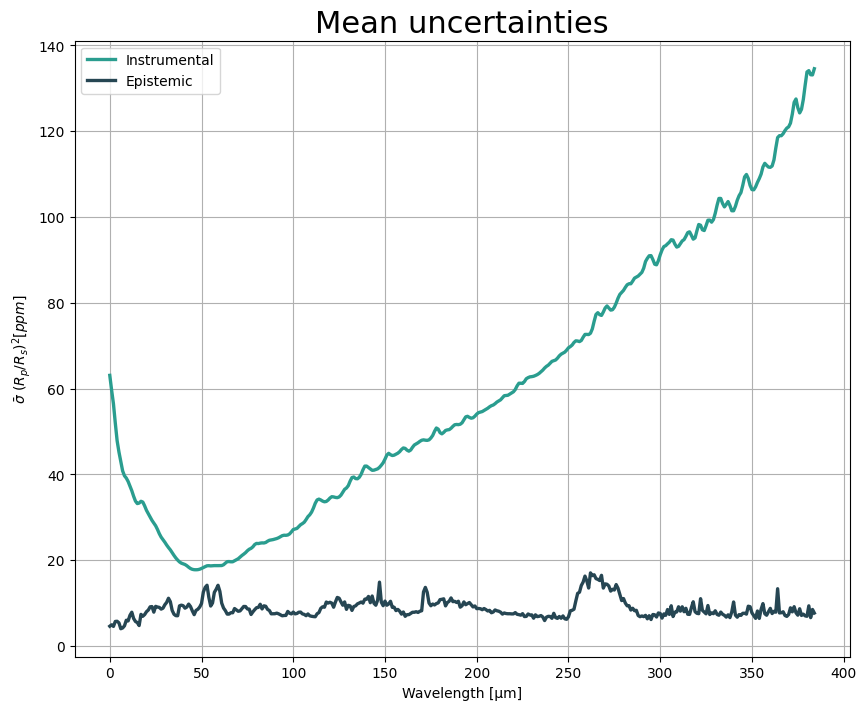

In [ ]:
wl_plot = wl[::-1]

plt.figure(figsize=(10, 8))
plt.plot(
    wl_plot,
    sigma_inst_d * 1e6,
    label="Instrumental",
    linewidth=2.4,
)
plt.plot(
    wl_plot,
    sigma_epi_med * 1e6,
    label="Epistemic (median across samples)",
    linewidth=2.4,
)

plt.xlabel("Wavelength [μm]")
plt.ylabel(r"$\bar{\sigma}$ $(R_p/R_s)^2$ [ppm]")
plt.title("Per-channel uncertainty summary", fontsize=22)
plt.legend()
plt.grid(True)
#plt.savefig("dae_uncertainties.png", dpi=300)
plt.show()

Indices seleccionados (Originales): [5, 331966, 13423]


C:\Users\User\AppData\Local\Temp\ipykernel_26228\1049567338.py:146: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)
C:\Users\User\AppData\Local\Temp\ipykernel_26228\1049567338.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


>>> Plot guardado: plots/exp0-final_style-RANDOM-IndependentAxes-total_uq-1Transit.png


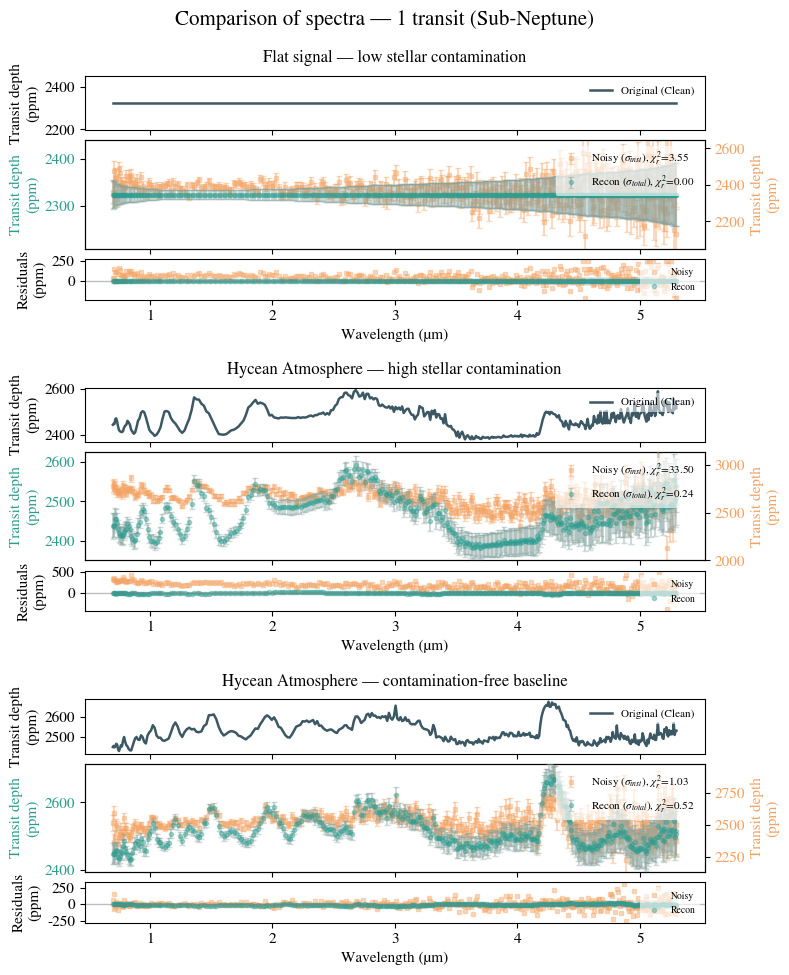

In [ ]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter


def _resolve_plot_arrays() -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """
    Resolve plotting arrays from the current notebook environment.

    Expected to exist (defined earlier in the notebook):
      - recon_mean
      - sigma_total
      - X_clean_raw
      - X_noisy_raw
      - errors
      - waves
    """
    y_recon_all = np.asarray(recon_mean)
    sigma_total_all = np.asarray(sigma_total)
    y_clean_all = np.asarray(X_clean_raw.values)
    y_noisy_all = np.asarray(X_noisy_raw.values)
    sigma_inst = np.asarray(errors)
    waves_i = np.asarray(waves)[::-1]
    return y_recon_all, sigma_total_all, y_clean_all, y_noisy_all, sigma_inst, waves_i


def _compute_offsets() -> tuple[int, int, int]:
    """
    Compute indexing constants for the concatenated dataset layout.

    Expected to exist:
      - NREP_PLANET, NREP_FLAT, k2_18b_contam
    """
    n_rep_p = int(NREP_PLANET)
    n_rep_f = int(NREP_FLAT)
    len_k2_original = int(len(k2_18b_contam))
    offset_flats = len_k2_original * n_rep_p
    return n_rep_p, n_rep_f, offset_flats


def create_plot_with_your_style(uncertainty_type: str) -> None:
    """
    Plot three randomly selected regimes with a 3-panel layout per regime:
      1) Clean spectrum
      2) Noisy vs reconstructed (twin y-axes, independent scaling)
      3) Residuals with uncertainty band

    Notes:
      - Uses *independent* y-limits for noisy and recon axes (more readable).
      - Adds chi2_reduced annotations in legend entries.

    Parameters
    ----------
    uncertainty_type
        Either "instrumental" or "total".
    """
    if uncertainty_type not in {"instrumental", "total"}:
        raise ValueError("uncertainty_type must be 'instrumental' or 'total'.")

    (
        y_recon_all,
        sigma_total_all,
        y_clean_all,
        y_noisy_all,
        sigma_inst,
        waves_i,
    ) = _resolve_plot_arrays()

    n_rep_p, n_rep_f, offset_flats = _compute_offsets()

    cand_flat = flat_contam[
        (flat_contam["f_fac"] == 0.133) & (flat_contam["f_spot"] == 0.1)
    ].index
    cand_high = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.400) & (k2_18b_contam["f_spot"] == 0.3)
    ].index
    cand_none = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.0) & (k2_18b_contam["f_spot"] == 0.0)
    ].index

    idx_flat = int(np.random.choice(cand_flat))
    idx_high = int(np.random.choice(cand_high))
    idx_none = int(np.random.choice(cand_none))

    idx_list_orig = [idx_flat, idx_high, idx_none]
    is_flat_mask = [True, False, False]

    print(f"Selected original indices: {idx_list_orig}")

    colors = {
        "original": "#264653",
        "reconstructed": "#2A9D8F",
        "noisy_points": "#F4A261",
        "fill_uq_resid": "#cccccc80",
    }

    titles = [
        "Flat signal — low stellar contamination",
        "Hycean atmosphere — high stellar contamination",
        "Hycean atmosphere — contamination-free baseline",
    ]

    plt.rcParams.update({"font.size": 11})

    n_groups = len(idx_list_orig)
    spacer = 2.5
    height_ratios: list[float] = []
    for i in range(n_groups):
        height_ratios.extend([2.0, 4.0, 1.5])
        if i < n_groups - 1:
            height_ratios.append(spacer)

    fig = plt.figure(figsize=(8, 11))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)

    for i, (idx_orig, is_flat) in enumerate(zip(idx_list_orig, is_flat_mask)):
        # Map a base index to a "replicate-expanded" index.
        if is_flat:
            start_pos = offset_flats + (idx_orig * n_rep_f)
            final_idx = start_pos + int(np.random.randint(0, n_rep_f))
        else:
            start_pos = idx_orig * n_rep_p
            final_idx = start_pos + int(np.random.randint(0, n_rep_p))

        base = 4 * i
        ax_clean = fig.add_subplot(gs[base])
        ax_mix = fig.add_subplot(gs[base + 1], sharex=ax_clean)
        ax_resid = fig.add_subplot(gs[base + 2], sharex=ax_clean)

        ax_clean.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        y_clean = y_clean_all[final_idx]
        y_noisy = y_noisy_all[final_idx]
        y_recon = y_recon_all[final_idx]

        if uncertainty_type == "instrumental":
            sigma_recon = sigma_inst
            recon_sigma_label = r"\sigma_{inst}"
        else:
            sigma_recon = sigma_total_all[final_idx]
            recon_sigma_label = r"\sigma_{total}"

        chi2r_noisy = chi2_reduced(
            y_clean[None, :],
            y_noisy[None, :],
            sigma_inst,
            p=0,
        )[0]
        chi2r_recon = chi2_reduced(
            y_clean[None, :],
            y_recon[None, :],
            sigma_recon,
            p=0,
        )[0]

        y_clean_ppm = y_clean * 1e6
        y_noisy_ppm = y_noisy * 1e6
        y_recon_ppm = y_recon * 1e6

        sigma_inst_ppm = sigma_inst * 1e6
        sigma_recon_ppm = sigma_recon * 1e6

        # Panel 1: Clean spectrum
        ax_clean.plot(
            waves_i,
            y_clean_ppm,
            color=colors["original"],
            linewidth=1.8,
            alpha=0.9,
            label="Original (Clean)",
        )
        ax_clean.set_ylabel("Transit depth\n(ppm)")
        ax_clean.set_title(titles[i], fontsize=12)

        leg1 = ax_clean.legend(
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.55,
        )
        leg1.set_zorder(1000)

        # Panel 2: Noisy vs Recon (twin y-axis)
        ax_mix_r = ax_mix.twinx()

        ax_clean.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3)
        ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0)
        ax_mix_r.patch.set_alpha(0.0)

        ax_mix.set_ylabel("Transit depth\n(ppm)", color=colors["reconstructed"])
        ax_mix.tick_params(axis="y", labelcolor=colors["reconstructed"])

        ax_mix_r.set_ylabel("Transit depth\n(ppm)", color=colors["noisy_points"])
        ax_mix_r.tick_params(axis="y", labelcolor=colors["noisy_points"])

        noisy_label = rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_noisy:.2f}"
        ax_mix_r.errorbar(
            waves_i,
            y_noisy_ppm,
            yerr=sigma_inst_ppm,
            color=colors["noisy_points"],
            fmt="s",
            capsize=2,
            alpha=0.4,
            markersize=3,
            zorder=8,
            label=noisy_label,
        )

        recon_label = rf"Recon ({recon_sigma_label}), $\chi^2_r$={chi2r_recon:.2f}"
        ax_mix.errorbar(
            waves_i,
            y_recon_ppm,
            yerr=sigma_recon_ppm,
            color=colors["reconstructed"],
            fmt="o",
            capsize=2,
            alpha=0.4,
            markersize=3,
            zorder=9,
            label=recon_label,
        )

        # Independent axis limits (each axis gets its own margins).
        y_min_rec, y_max_rec = float(np.min(y_recon_ppm)), float(np.max(y_recon_ppm))
        y_min_noi, y_max_noi = float(np.min(y_noisy_ppm)), float(np.max(y_noisy_ppm))

        margin_rec = (y_max_rec - y_min_rec) * 0.15
        margin_noi = (y_max_noi - y_min_noi) * 0.15

        ax_mix.set_ylim(y_min_rec - margin_rec, y_max_rec + margin_rec)
        ax_mix_r.set_ylim(y_min_noi - margin_noi, y_max_noi + margin_noi)

        lines_left, labels_left = ax_mix.get_legend_handles_labels()
        lines_right, labels_right = ax_mix_r.get_legend_handles_labels()

        leg2 = ax_mix.legend(
            lines_right + lines_left,
            labels_right + labels_left,
            fontsize=8,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )
        leg2.set_zorder(1000)

        # Panel 3: Residuals + uncertainty band
        resid_noisy = (y_noisy - y_clean) * 1e6
        resid_recon = (y_recon - y_clean) * 1e6

        ax_resid.fill_between(
            waves_i,
            -sigma_recon_ppm,
            sigma_recon_ppm,
            color=colors["fill_uq_resid"],
            zorder=0 if uncertainty_type == "total" else 5,
        )

        ax_resid.plot(
            waves_i,
            resid_noisy,
            "s",
            color=colors["noisy_points"],
            alpha=0.4,
            markersize=3,
            label="Noisy",
            zorder=1,
        )
        ax_resid.plot(
            waves_i,
            resid_recon,
            "o",
            color=colors["reconstructed"],
            alpha=0.4,
            markersize=3,
            label="Recon",
            zorder=2,
        )

        ax_resid.axhline(0.0, color="gray", linewidth=1.0, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)")
        ax_resid.set_xlabel("Wavelength (µm)", fontsize=11)
        ax_resid.legend(
            fontsize=7,
            loc="upper right",
            frameon=True,
            fancybox=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.65,
        )

    transit_text = (
        f"{T_TRANSITS} transit(s)" if "T_TRANSITS" in globals() else "transits"
    )
    fig.suptitle(
        f"Comparison of spectra — {transit_text} (Sub-Neptune)",
        fontsize=15,
        y=0.94,
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    os.makedirs("plots", exist_ok=True)
    out_base = (
        f"plots/exp0-final_style-RANDOM-IndependentAxes-"
        f"{uncertainty_type}_uq"
    )
    #plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
    #print(f">>> Saved plot: {out_base}.png")
    plt.show()


create_plot_with_your_style(uncertainty_type="total")


Indices seleccionados (Base): [5, 339747, 11020]


C:\Users\User\AppData\Local\Temp\ipykernel_26228\4208942961.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.0, 1, 0.93], h_pad=0.5)


>>> Plot guardado: plots/final_random_selection-total_uq.png


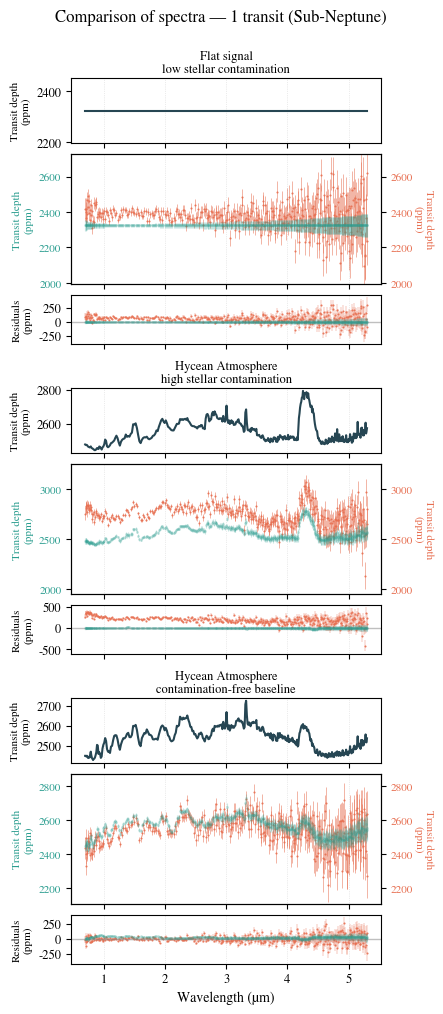

In [ ]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter


def _resolve_plot_arrays() -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """
    Resolve plotting arrays from the current notebook environment.

    Expected to exist:
      - recon_mean, sigma_total, X_clean_raw, X_noisy_raw, errors, waves
    """
    y_recon_all = np.asarray(recon_mean)
    sigma_total_all = np.asarray(sigma_total)
    y_clean_all = np.asarray(X_clean_raw.values)
    y_noisy_all = np.asarray(X_noisy_raw.values)
    sigma_inst = np.asarray(errors)
    waves_i = np.asarray(waves)[::-1]
    return y_recon_all, sigma_total_all, y_clean_all, y_noisy_all, sigma_inst, waves_i


def _compute_offsets() -> tuple[int, int, int]:
    """
    Compute indexing constants for the concatenated dataset layout.

    Expected to exist:
      - NREP_PLANET, NREP_FLAT, k2_18b_contam
    """
    n_rep_p = int(NREP_PLANET)
    n_rep_f = int(NREP_FLAT)
    len_k2_original = int(len(k2_18b_contam))
    offset_flats = len_k2_original * n_rep_p
    return n_rep_p, n_rep_f, offset_flats


def create_plot_random_selection(uncertainty_type: str) -> None:
    """
    Compact 3×(clean/mix/residual) plot with serif styling.

    Key differences vs. Plot A:
      - More compact canvas and tighter typography.
      - Syncs y-limits between noisy/recon axes (single combined range).
      - Adds light x-grid guides for visual alignment.

    Parameters
    ----------
    uncertainty_type
        Either "instrumental" or "total".
    """
    if uncertainty_type not in {"instrumental", "total"}:
        raise ValueError("uncertainty_type must be 'instrumental' or 'total'.")

    (
        y_recon_all,
        sigma_total_all,
        y_clean_all,
        y_noisy_all,
        sigma_inst,
        waves_i,
    ) = _resolve_plot_arrays()

    n_rep_p, n_rep_f, offset_flats = _compute_offsets()

    cand_flat = flat_contam[
        (flat_contam["f_fac"] == 0.133) & (flat_contam["f_spot"] == 0.1)
    ].index
    cand_high = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.400) & (k2_18b_contam["f_spot"] == 0.3)
    ].index
    cand_none = k2_18b_contam[
        (k2_18b_contam["f_fac"] == 0.0) & (k2_18b_contam["f_spot"] == 0.0)
    ].index

    idx_flat = int(np.random.choice(cand_flat))
    idx_high = int(np.random.choice(cand_high))
    idx_none = int(np.random.choice(cand_none))

    idx_list_orig = [idx_flat, idx_high, idx_none]
    is_flat_mask = [True, False, False]

    print(f"Selected base indices: {idx_list_orig}")

    colors = {
        "original": "#264653",
        "reconstructed": "#2A9D8F",
        "noisy_points": "#E76F51",
        "fill_uq_resid": "#cccccc80",
    }

    titles = [
        "Flat signal\nlow stellar contamination",
        "Hycean Atmosphere\nhigh stellar contamination",
        "Hycean Atmosphere\ncontamination-free baseline",
    ]

    plt.rcParams.update({"font.size": 9, "font.family": "serif"})

    n_groups = len(idx_list_orig)
    spacer = 0.7
    height_ratios: list[float] = []
    for i in range(n_groups):
        height_ratios.extend([2.0, 4.0, 1.5])
        if i < n_groups - 1:
            height_ratios.append(spacer)

    fig = plt.figure(figsize=(4, 11.5))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)

    main_ax = None

    for i, (idx_orig, is_flat) in enumerate(zip(idx_list_orig, is_flat_mask)):
        if is_flat:
            start_pos = offset_flats + (idx_orig * n_rep_f)
            final_idx = start_pos + int(np.random.randint(0, n_rep_f))
        else:
            start_pos = idx_orig * n_rep_p
            final_idx = start_pos + int(np.random.randint(0, n_rep_p))

        base = 4 * i

        if main_ax is None:
            ax_clean = fig.add_subplot(gs[base])
            main_ax = ax_clean
        else:
            ax_clean = fig.add_subplot(gs[base], sharex=main_ax)

        ax_mix = fig.add_subplot(gs[base + 1], sharex=main_ax)
        ax_resid = fig.add_subplot(gs[base + 2], sharex=main_ax)

        # Light x-grid to help track wavelength alignment across panels.
        for ax in (ax_clean, ax_mix, ax_resid):
            ax.grid(
                axis="x",
                color="gray",
                linestyle=":",
                linewidth=0.5,
                alpha=0.3,
            )

        ax_clean.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        if i < n_groups - 1:
            ax_resid.tick_params(labelbottom=False)
        else:
            ax_resid.tick_params(labelbottom=True)
            ax_resid.set_xlabel("Wavelength (µm)", fontsize=10)

        y_clean = y_clean_all[final_idx]
        y_noisy = y_noisy_all[final_idx]
        y_recon = y_recon_all[final_idx]

        sigma_recon = sigma_inst if uncertainty_type == "instrumental" else sigma_total_all[
            final_idx
        ]

        y_clean_ppm = y_clean * 1e6
        y_noisy_ppm = y_noisy * 1e6
        y_recon_ppm = y_recon * 1e6

        sigma_inst_ppm = sigma_inst * 1e6
        sigma_recon_ppm = sigma_recon * 1e6

        # Panel 1: Clean
        ax_clean.plot(
            waves_i,
            y_clean_ppm,
            color=colors["original"],
            linewidth=1.5,
            alpha=1.0,
        )
        ax_clean.set_ylabel("Transit depth\n(ppm)", fontsize=8)
        ax_clean.set_title(titles[i], fontsize=9, pad=4)

        # Panel 2: Mix (twin axis)
        ax_mix_r = ax_mix.twinx()

        ax_clean.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3)
        ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0)
        ax_mix_r.patch.set_alpha(0.0)

        ax_mix.set_ylabel(
            "Transit depth\n(ppm)",
            color=colors["reconstructed"],
            fontsize=8,
        )
        ax_mix.tick_params(
            axis="y",
            labelcolor=colors["reconstructed"],
            labelsize=8,
        )

        ax_mix_r.set_ylabel(
            "Transit depth\n(ppm)",
            color=colors["noisy_points"],
            fontsize=8,
            rotation=270,
            labelpad=15,
        )
        ax_mix_r.tick_params(
            axis="y",
            labelcolor=colors["noisy_points"],
            labelsize=8,
        )

        # Noisy (orange/red)
        ax_mix_r.errorbar(
            waves_i,
            y_noisy_ppm,
            yerr=sigma_inst_ppm,
            color=colors["noisy_points"],
            fmt="o",
            alpha=0.9,
            markersize=1.5,
            markeredgewidth=0.0,
            elinewidth=0.4,
            capsize=0,
            zorder=1,
        )

        # Recon (green)
        ax_mix.errorbar(
            waves_i,
            y_recon_ppm,
            yerr=sigma_recon_ppm,
            color=colors["reconstructed"],
            fmt="o",
            alpha=0.25,
            markersize=2.0,
            markeredgewidth=0.0,
            elinewidth=0.8,
            capsize=0,
            zorder=10,
        )

        # Synced y-limits between both axes (single combined range).
        all_vals = np.concatenate([y_noisy_ppm, y_recon_ppm])
        y_min, y_max = float(np.min(all_vals)), float(np.max(all_vals))
        margin = (y_max - y_min) * 0.20
        ax_mix.set_ylim(y_min - margin, y_max + margin)
        ax_mix_r.set_ylim(y_min - margin, y_max + margin)

        # Panel 3: Residuals
        resid_noisy = (y_noisy - y_clean) * 1e6
        resid_recon = (y_recon - y_clean) * 1e6

        fill_z = 5 if uncertainty_type == "instrumental" else 0
        ax_resid.fill_between(
            waves_i,
            -sigma_recon_ppm,
            sigma_recon_ppm,
            color=colors["fill_uq_resid"],
            zorder=fill_z,
            alpha=0.25,
        )

        ax_resid.errorbar(
            waves_i,
            resid_noisy,
            yerr=sigma_inst_ppm,
            fmt="o",
            color=colors["noisy_points"],
            alpha=0.9,
            markersize=1.5,
            markeredgewidth=0.0,
            elinewidth=0.3,
            zorder=1,
        )

        ax_resid.errorbar(
            waves_i,
            resid_recon,
            yerr=sigma_recon_ppm,
            fmt="o",
            color=colors["reconstructed"],
            alpha=0.25,
            markersize=2.0,
            markeredgewidth=0.0,
            elinewidth=0.6,
            zorder=2,
        )

        ax_resid.axhline(0.0, color="gray", linewidth=1.0, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)", fontsize=8)

    transit_text = f"{N_TRANSITS} transits" if "N_TRANSITS" in globals() else "transits"
    fig.suptitle(
        f"Comparison of spectra — {transit_text} (Sub-Neptune)",
        fontsize=12,
        y=0.94,
    )

    plt.tight_layout(rect=[0, 0.0, 1, 0.93], h_pad=0.5)

    os.makedirs("plots", exist_ok=True)
    out_base = f"plots/final_random_selection-{uncertainty_type}_uq"
    #plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
    #print(f">>> Saved plot: {out_base}.png")
    plt.show()


create_plot_random_selection(uncertainty_type="total")


# Experiment B — Multi-transit sensitivity 

In [ ]:
k2_18b_mult = mult_df(k2_18b, n_points=385, n_mult=0)
flat_mult = mult_df(flat, n_points=385, n_mult=0)

print(k2_18b_mult.shape)
print(k2_18b_mult.params.columns[:10])
print(k2_18b_mult.data.shape)


In [ ]:
N_TRANSITS_LIST = [1, 2, 5, 10]

NREP_PLANET = 3
NREP_FLAT = 300
T_PASSES_DROPOUT = 50
EPS_SIGMA = 1e-12

WL_GRID_SIM = np.linspace(0.6, 5.3, 1000)


def filter_by_stellar_params(
    df: pd.DataFrame,
    f_spot_val: float,
    f_fac_val: float,
) -> pd.DataFrame:
    mask = (df["f_spot"] == f_spot_val) & (df["f_fac"] == f_fac_val)
    return df.loc[mask]


unique_f_spot = np.sort(flat_contam["f_spot"].unique())
unique_f_fac = np.sort(flat_contam["f_fac"].unique())

print(f">>> Unique f_spot: {unique_f_spot}")
print(f">>> Unique f_fac:  {unique_f_fac}")

print("Building master CLEAN dataset (one-time)...")
df_clean_master = pd.concat(
    [
        generate_df_with_noise_std(k2_18b_mult, NREP_PLANET, 0.0),
        generate_df_with_noise_std(flat_mult, NREP_FLAT, 0.0),
    ],
    ignore_index=True,
)
print(f"Master CLEAN dataset ready. Shape: {df_clean_master.shape}")

all_results: dict[tuple[float, float], dict[str, list]] = {}
print("\nStarting sensitivity & UQ analysis...")

for f_spot_val in unique_f_spot:
    for f_fac_val in unique_f_fac:
        df_clean_filtered = df_clean_master

        if df_clean_filtered.empty:
            continue

        x_clean_raw = df_clean_filtered.iloc[:, -n_points:]

        scores: dict[str, list] = {
            "n_transits": [],
            "chi2r_noisy_clean_inst": [],
            "chi2r_recon_clean_inst": [],
            "chi2r_recon_clean_total": [],
            "sigma_inst_mean_lambda": [],
            "sigma_ale_mean_lambda": [],
            "sigma_epi_mean_lambda": [],
            "sigma_total_mean_lambda": [],
        }

        desc = f"Processing f_spot={f_spot_val}, f_fac={f_fac_val}"

        for nt in tqdm(N_TRANSITS_LIST, desc=desc, leave=False):
            _, instrumental_noise = get_k218_prism_noise_flat(
                wl_grid_um=WL_GRID_SIM,
                n_transits=nt,
                T_s=3500.0,
                plot=False,
                cut_first=18,
            )

            instrumental_noise = instrumental_noise[::-1]
            if instrumental_noise.shape[0] != n_points:
                instrumental_noise = instrumental_noise[:n_points]

            df_noisy = pd.concat(
                [
                    generate_df_with_noise_std(
                        k2_18b_contam, NREP_PLANET, instrumental_noise
                    ),
                    generate_df_with_noise_std(
                        flat_contam, NREP_FLAT, instrumental_noise
                    ),
                ],
                ignore_index=True,
            )

            df_noisy_filtered = filter_by_stellar_params(
                df_noisy, f_spot_val, f_fac_val
            )
            if df_noisy_filtered.empty:
                continue

            x_noisy_raw = df_noisy_filtered.iloc[:, -n_points:]

            sigma_ale = calc_aleatoric_half_instrumental(
                sigma_inst=instrumental_noise,
                shape=x_noisy_raw.shape,
            )

            mean_dropout, sigma_epi = mc_dropout_sigma_anchor_clean(
                autoencoder=autoencoder,
                x_noisy_raw=x_noisy_raw,
                x_clean_raw=x_clean_raw,
                t_passes=T_PASSES_DROPOUT,
            )

            sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)
            recon_mean = mean_dropout

            sigma_inst_mean_lambda = instrumental_noise.astype(np.float32)
            sigma_ale_mean_lambda = np.nanmean(sigma_ale, axis=0).astype(np.float32)
            sigma_epi_mean_lambda = np.nanmean(sigma_epi, axis=0).astype(np.float32)
            sigma_total_mean_lambda = np.nanmean(sigma_total, axis=0).astype(np.float32)

            chi2r_1 = chi2_reduced(
                x_clean_raw.values,
                x_noisy_raw.values,
                instrumental_noise,
                p=0,
            )
            chi2r_2 = chi2_reduced(
                x_clean_raw.values,
                recon_mean,
                instrumental_noise,
                p=0,
            )
            chi2r_3 = chi2_reduced(
                x_clean_raw.values,
                recon_mean,
                sigma_total,
                p=0,
            )

            scores["n_transits"].append(nt)
            scores["chi2r_noisy_clean_inst"].append(float(np.mean(chi2r_1)))
            scores["chi2r_recon_clean_inst"].append(float(np.mean(chi2r_2)))
            scores["chi2r_recon_clean_total"].append(float(np.mean(chi2r_3)))
            scores["sigma_inst_mean_lambda"].append(sigma_inst_mean_lambda)
            scores["sigma_ale_mean_lambda"].append(sigma_ale_mean_lambda)
            scores["sigma_epi_mean_lambda"].append(sigma_epi_mean_lambda)
            scores["sigma_total_mean_lambda"].append(sigma_total_mean_lambda)

            del df_noisy, df_noisy_filtered, x_noisy_raw, recon_mean, sigma_total

        all_results[(float(f_spot_val), float(f_fac_val))] = scores
        gc.collect()

print("\nDone!")

output_filename = "results_sensitivity_uq_final.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(all_results, f)

print(f">>> Results saved to: '{output_filename}'")


<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_76392\2932864813.py:81: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')


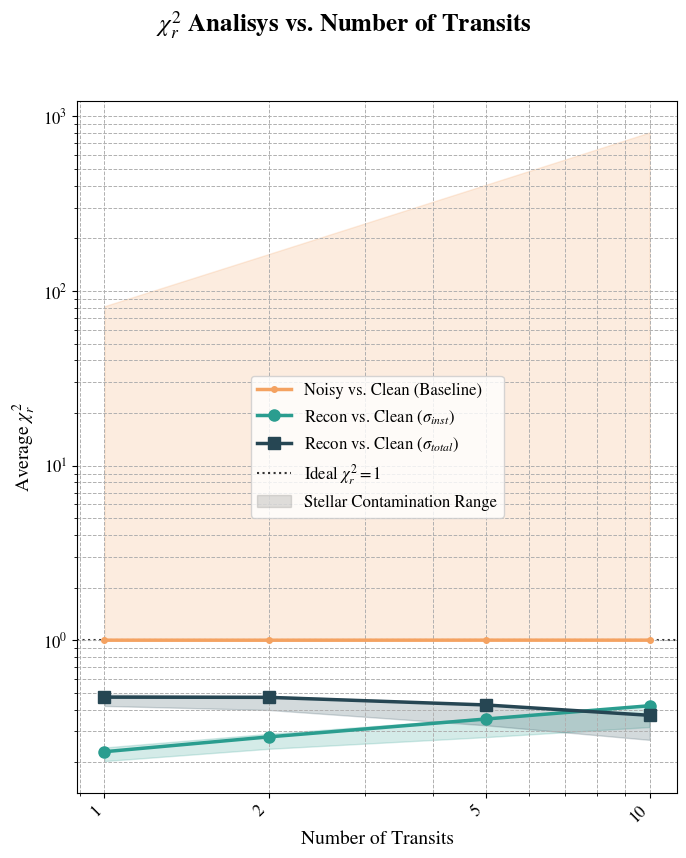

In [ ]:
def load_results(path: str) -> dict[tuple[float, float], dict[str, list]]:
    with open(path, "rb") as f:
        return pickle.load(f)


def get_min_max_across_cases(
    metric: str,
    transit_list: list[int],
    results: dict[tuple[float, float], dict[str, list]],
) -> tuple[np.ndarray, np.ndarray]:
    mins: list[float] = []
    maxs: list[float] = []

    for nt in transit_list:
        vals: list[float] = []
        for data in results.values():
            if nt not in data["n_transits"]:
                continue
            idx = data["n_transits"].index(nt)
            v = data[metric][idx]
            if np.isfinite(v):
                vals.append(float(v))

        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
        else:
            mins.append(np.nan)
            maxs.append(np.nan)

    return np.asarray(mins, dtype=float), np.asarray(maxs, dtype=float)


filename = "results_sensitivity_uq_final.pkl"
results = load_results(filename)

base_key = (0.0, 0.0)
case_base = results.get(base_key)
if case_base is None:
    raise RuntimeError("Missing base case for (f_spot=0, f_fac=0).")

transits_plot = case_base["n_transits"]
x_vals = np.asarray(transits_plot, dtype=float)

metrics = [
    "chi2r_noisy_clean_inst",
    "chi2r_recon_clean_inst",
    "chi2r_recon_clean_total",
]

legend_labels = {
    "chi2r_noisy_clean_inst": r"Noisy vs. Clean (Baseline)",
    "chi2r_recon_clean_inst": r"Recon vs. Clean ($\sigma_{inst}$)",
    "chi2r_recon_clean_total": r"Recon vs. Clean ($\sigma_{total}$)",
}

palette = {
    "chi2r_noisy_clean_inst": "#F4A261",
    "chi2r_recon_clean_inst": "#2A9D8F",
    "chi2r_recon_clean_total": "#264653",
}

markers = {
    "chi2r_noisy_clean_inst": ".",
    "chi2r_recon_clean_inst": "o",
    "chi2r_recon_clean_total": "s",
}

fig, ax = plt.subplots(figsize=(7, 9))
fig.suptitle(
    r"$\chi^2_r$ Analysis vs. Number of Transits",
    fontsize=18,
    y=0.98,
    weight="bold",
)

for metric in metrics:
    color = palette[metric]
    mn, mx = get_min_max_across_cases(metric, transits_plot, results)
    ax.fill_between(x_vals, mn, mx, color=color, alpha=0.20)

    y_base = [
        case_base[metric][case_base["n_transits"].index(nt)]
        if nt in case_base["n_transits"]
        else np.nan
        for nt in transits_plot
    ]
    ax.plot(
        x_vals,
        y_base,
        marker=markers[metric],
        markersize=8,
        color=color,
        linewidth=2.5,
        label=legend_labels[metric],
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"Average $\chi^2_r$", fontsize=14)
ax.set_xlabel("Number of Transits", fontsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.7)
ax.tick_params(axis="both", which="major", labelsize=12)

ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    zorder=0,
    label=r"Ideal $\chi^2_r = 1$",
)

handles, labels = ax.get_legend_handles_labels()
handles.append(plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.25))
labels.append("Stellar Contamination Range")
ax.legend(handles=handles, labels=labels, fontsize=12, loc="best")

ax.set_xticks(transits_plot)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig(os.path.join(output_dir, "chi2r_analysis_all.png"), dpi=300)
#plt.savefig(os.path.join(output_dir, "chi2r_analysis_all.svg"))
plt.show()


<>:78: SyntaxWarning: invalid escape sequence '\c'
<>:78: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_38860\1342259057.py:78: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analysis: Impact of Stellar Activity', fontsize=18, y=0.96, weight='bold')
C:\Users\User\AppData\Local\Temp\ipykernel_38860\1342259057.py:177: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 4
  ax.legend(handles=handles, labels=labels_ax, fontsize=9, loc='upper left', framealpha=0.7)


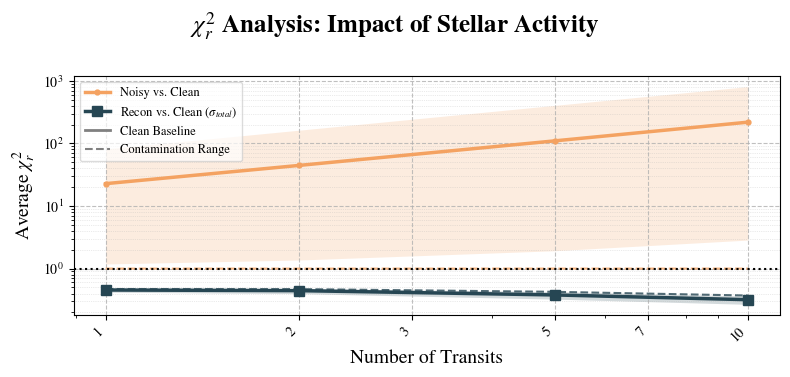

In [ ]:
def load_results(path: str) -> dict[tuple[float, float], dict[str, list]]:
    with open(path, "rb") as f:
        return pickle.load(f)


def contaminated_stats(
    metric: str,
    transits: list[int],
    results: dict[tuple[float, float], dict[str, list]],
    base_key: tuple[float, float],
) -> tuple[list[float], list[float], list[float]]:
    mins: list[float] = []
    maxs: list[float] = []
    means: list[float] = []

    for nt in transits:
        vals: list[float] = []
        for key, data in results.items():
            if key == base_key:
                continue
            if nt not in data["n_transits"]:
                continue
            idx = data["n_transits"].index(nt)
            v = data[metric][idx]
            if np.isfinite(v):
                vals.append(float(v))

        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
            means.append(float(np.mean(vals)))
        else:
            mins.append(np.nan)
            maxs.append(np.nan)
            means.append(np.nan)

    return mins, maxs, means


filename = "results_sensitivity_uq_final.pkl"
results = load_results(filename)

base_key = (0.0, 0.0)
case_base = results.get(base_key)
if case_base is None:
    raise RuntimeError("Missing base case for (f_spot=0, f_fac=0).")

transits_plot = case_base["n_transits"]

metrics = [
    "chi2r_noisy_clean_inst",
    "chi2r_recon_clean_total",
]

metric_labels = {
    "chi2r_noisy_clean_inst": r"Noisy vs. Clean",
    "chi2r_recon_clean_total": r"Recon vs. Clean ($\sigma_{total}$)",
}

palette = {
    "chi2r_noisy_clean_inst": "#F4A261",
    "chi2r_recon_clean_total": "#264653",
}

markers = {
    "chi2r_noisy_clean_inst": ".",
    "chi2r_recon_clean_total": "s",
}

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(
    r"$\chi^2_r$ Analysis: Impact of Stellar Activity",
    fontsize=18,
    y=0.96,
    weight="bold",
)

for metric in metrics:
    color = palette[metric]
    marker = markers[metric]

    mins, maxs, means = contaminated_stats(metric, transits_plot, results, base_key)

    ax.fill_between(
        transits_plot,
        mins,
        maxs,
        color=color,
        alpha=0.2,
        linewidth=0.0,
    )

    ax.plot(
        transits_plot,
        means,
        marker=marker,
        markersize=7,
        color=color,
        linewidth=2.5,
        linestyle="-",
        label=metric_labels[metric],
    )

    y_base = [
        case_base[metric][case_base["n_transits"].index(nt)]
        if nt in case_base["n_transits"]
        else np.nan
        for nt in transits_plot
    ]
    ax.plot(
        transits_plot,
        y_base,
        color=color,
        linewidth=1.5,
        linestyle="--",
        alpha=0.8,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"Average $\chi^2_r$", fontsize=14)
ax.set_xlabel("Number of Transits", fontsize=14)

custom_ticks = sorted(set(transits_plot) | {3, 7})
ax.set_xticks(custom_ticks)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

locmin = mticker.LogLocator(
    base=10.0,
    subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
    numticks=12,
)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.8)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.5)

ax.axhline(1.0, color="black", linestyle=":", linewidth=1.5)

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color="gray", linestyle="--", linewidth=1.5))
labels.append("Clean Baseline")
handles.append(plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.2))
labels.append("Contamination Range")
ax.legend(handles=handles, labels=labels, fontsize=9, loc="upper left", framealpha=0.7)

output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig(
#    os.path.join(output_dir, "exp3-chi2r_analysis_final_02-comp.png"),
#    dpi=500,
#)
plt.show()


# Experiment C - N+1 Molecule (DMS)

In this final experiment, we test how the G-DAE model behaves when encountering a molecule it has never seen during training. This is a classic "out-of-distribution" (OOD) test.

We use **Dimethyl Sulfide (DMS)** as our OOD molecule, injecting it into the reference chemistry of a planetary atmosphere. Our goal is to see if the model can still reconstruct the spectrum under stellar contamination, and how its uncertainty ($\sigma_{epi}$) behaves when the OOD signal becomes strong.

The workflow is straightforward:
1. Generate synthetic transit spectra for a Hycean-like atmosphere featuring **DMS**.
2. Apply the same contamination and instrumental noise used in previous experiments.
3. Restrict our evaluation to a long-wavelength window ($\lambda \ge 4.0 \, \mu m$) where differences driven by DMS are more pronounced.

## Step 1 - Define the Chemistry and Simulate the DMS Spectra

We want a robust test case, so our background chemistry is fixed explicitly:
- `CO2 = -2.0`
- `CH4 = -1.0`
- `H2O = -3.0`
- `NH3 = -5.0`

On top of this, we configure a grid for **DMS** ranging from extremely weak ($\log_{10} = -10$) to very strong ($\log_{10} = -2$). 

We compute the grid computationally and use these generated spectra straight away.

In [11]:
from matplotlib.colors import LinearSegmentedColormap, LogNorm, TwoSlopeNorm

NPLUS1_OOD_GAS = "DMS"
NPLUS1_DMS_PARAMETER_SPACE = {"min": -10.0, "max": -2.0, "n": 9}
NPLUS1_DMS_GRID = np.linspace(
    NPLUS1_DMS_PARAMETER_SPACE["min"],
    NPLUS1_DMS_PARAMETER_SPACE["max"],
    NPLUS1_DMS_PARAMETER_SPACE["n"],
)
NPLUS1_FIXED_GASES = {
    "CO2": -2.0,
    "CH4": -1.0,
    "H2O": -3.0,
    "NH3": -5.0,
}
NPLUS1_TRANSITS_LIST = [1, 2, 5]
NPLUS1_NOISE_REPEATS = 100

spectral_columns = list(k2_18b.columns[-n_points:])
base_param_columns = list(k2_18b.columns[:-n_points])
param_columns_nplus1 = base_param_columns.copy()
if "atm DMS" not in param_columns_nplus1:
    insert_at = param_columns_nplus1.index("atm NH3") + 1
    param_columns_nplus1.insert(insert_at, "atm DMS")


In [12]:
import multirex as mrex

# Build the same Hycean-like system used in the synthetic-spectrum notebook.
star = mrex.Star(
    temperature=3500,
    radius=0.468,
    mass=0.495,
    phoenix_path="",
)
planet = mrex.Planet(
    radius=2.461,
    mass=7.2,
)
atmosphere = mrex.Atmosphere(
    temperature=250,
    base_pressure=10e5,
    top_pressure=1e-3,
    fill_gas=["H2", "He"],
    cia=["H2-H2", "H2-He"],
)
planet.set_atmosphere(atmosphere)

system_dms = mrex.System(
    planet=planet,
    star=star,
    sma=0.1429,
)

# Reuse the same CIA setup as before.
mrex.Util.get_CIAs(["H2-H2", "H2-He"], path="CIA")

# Here the grid is only one-dimensional in the new molecule.
parameter_space_dms = {
    "planet.atmosphere.temperature": [250.0],
    "planet.atmosphere.composition.CO2": [NPLUS1_FIXED_GASES["CO2"]],
    "planet.atmosphere.composition.CH4": [NPLUS1_FIXED_GASES["CH4"]],
    "planet.atmosphere.composition.H2O": [NPLUS1_FIXED_GASES["H2O"]],
    "planet.atmosphere.composition.NH3": [NPLUS1_FIXED_GASES["NH3"]],
    "planet.atmosphere.composition.DMS": dict(NPLUS1_DMS_PARAMETER_SPACE),
}
print("Parameter space used for DMS:")
print(parameter_space_dms)

dms_clean_df = system_dms.explore_parameter_space(
    wn_grid=wn_grid,
    parameter_space=parameter_space_dms,
    header=True,
    observations=False,
    n_jobs=-1,
)
dms_clean_df = dms_clean_df.copy()

if "atm DMS" not in dms_clean_df.columns:
    raise KeyError("The generated dataframe does not contain the column 'atm DMS'.")

dms_clean_df = dms_clean_df[param_columns_nplus1 + spectral_columns].copy()
dms_clean_df.data = dms_clean_df.iloc[:, -n_points:]
dms_clean_df.params = dms_clean_df.iloc[:, :-n_points]

print(dms_clean_df[["atm CO2", "atm CH4", "atm H2O", "atm NH3", "atm DMS"]])


Numba not installed, using numpy instead
Loading MultiREx version 0.3.1
The directory to Phoenix already exists in the specified path:  current directory
Parameter space used for DMS:
{'planet.atmosphere.temperature': [250.0], 'planet.atmosphere.composition.CO2': [-2.0], 'planet.atmosphere.composition.CH4': [-1.0], 'planet.atmosphere.composition.H2O': [-3.0], 'planet.atmosphere.composition.NH3': [-5.0], 'planet.atmosphere.composition.DMS': {'min': -10.0, 'max': -2.0, 'n': 9}}


100%|██████████| 9/9 [00:00<00:00, 1056.23it/s]


   atm CO2  atm CH4  atm H2O  atm NH3  atm DMS
0     -2.0     -1.0     -3.0     -5.0    -10.0
1     -2.0     -1.0     -3.0     -5.0     -9.0
2     -2.0     -1.0     -3.0     -5.0     -8.0
3     -2.0     -1.0     -3.0     -5.0     -7.0
4     -2.0     -1.0     -3.0     -5.0     -6.0
5     -2.0     -1.0     -3.0     -5.0     -5.0
6     -2.0     -1.0     -3.0     -5.0     -4.0
7     -2.0     -1.0     -3.0     -5.0     -3.0
8     -2.0     -1.0     -3.0     -5.0     -2.0


C:\Users\User\AppData\Local\Temp\ipykernel_43160\875093392.py:57: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dms_clean_df.data = dms_clean_df.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\875093392.py:58: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dms_clean_df.params = dms_clean_df.iloc[:, :-n_points]


### Quick inspection of the clean spectra

Before applying contamination or instrumental noise, let's take a rapid look at a few examples natively generated. We can clearly observe how DMS starts altering the long wavelengths when reaching higher abundances.

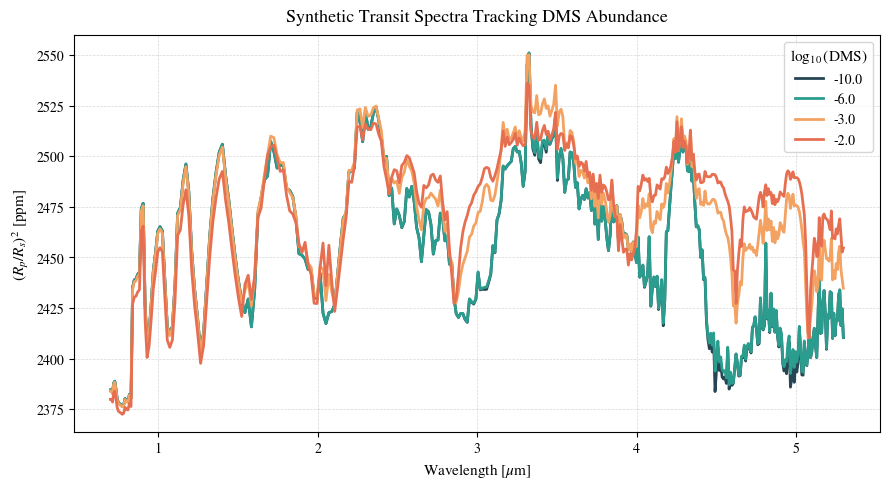

In [13]:
# Convert DMS column to an array outside the loop for efficiency
dms_array = pd.to_numeric(dms_clean_df["atm DMS"], errors="coerce").to_numpy(dtype=float)
wavelengths = np.asarray(waves, dtype=float)

fig, ax = plt.subplots(figsize=(9, 5))

dms_levels = [-10.0, -6.0, -3.0, -2.0]
colors = ["#264653", "#2A9D8F", "#F4A261", "#E76F51"]

for dms_value, color in zip(dms_levels, colors):
    # Find the row matching the specific DMS abundance
    dms_mask = np.isclose(dms_array, dms_value)
    spectrum = dms_clean_df.loc[dms_mask, spectral_columns].iloc[0]
    
    # Extract values, reverse to match wavelength ordering, and convert to ppm
    spectrum_ppm = spectrum.to_numpy(dtype=float)[::-1] * 1e6
    
    ax.plot(
        wavelengths,
        spectrum_ppm,
        color=color,
        linewidth=2.0,
        label=f"{dms_value:.1f}"
    )

ax.set_xlabel(r"Wavelength [$\mu$m]", fontsize=11)
ax.set_ylabel(r"$(R_p/R_s)^2$ [ppm]", fontsize=11)
ax.set_title("Synthetic Transit Spectra Tracking DMS Abundance", fontsize=13, pad=10)

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(title=r"$\log_{10}(\mathrm{DMS})$", fontsize=10, title_fontsize=11, framealpha=0.8)

plt.tight_layout()
plt.show()

## Step 2 - Add Stellar Contamination and Instrumental Noise

To ensure a fair evaluation against previous stages, we apply the exact same noise methods and procedures we've been using across the notebook.

This step performs two tasks:
- First, we multiply the clean templates into multiple versions using known contamination coefficients (`apply_contaminations_from_files`).
- Second, we calculate noise vectors across several distinct integration scenarios (1, 2, or 5 transits). 

By isolating the noise definition into a dictionary mapped to the number of transits, we make evaluation simple and repeatable later.

In [14]:
# Use the same stellar-contamination procedure already defined earlier.
dms_contam = apply_contaminations_from_files(
    contamination_files=contamination_files,
    df=dms_clean_df,
    n_points=n_points,
)

dms_clean_mult = mult_df(
    dms_clean_df,
    n_points=n_points,
    n_mult=len(contamination_files) - 1,
)

print("Contaminated DMS dataframe:", dms_contam.shape)
print("Clean replicated DMS dataframe:", dms_clean_mult.shape)
print(dms_contam[["f_spot", "f_fac", "atm DMS"]].head())

# Build one instrumental-noise vector per transit count.
sigma_by_transit = {}
wl_grid_sim = np.linspace(0.6, 5.3, 1000)
for nt in NPLUS1_TRANSITS_LIST:
    waves_pdx, sigma_raw = get_k218_prism_noise_flat(
        wl_grid_um=wl_grid_sim,
        n_transits=int(nt),
        t_star=TSTAR_K218,
        plot=False,
        cut_first=18,
    )
    sigma_by_transit[int(nt)] = resample_sigma_to_target_grid(
        waves_src=waves_pdx[::-1],
        sigma_src=sigma_raw[::-1],
        waves_tgt=waves,
    ).astype(np.float32)

print("Transit counts with cached sigma_inst:", list(sigma_by_transit))

C:\Users\User\AppData\Local\Temp\ipykernel_43160\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_43160\960156845.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_43160\960156845.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

Contaminated DMS dataframe: (144, 410)
Clean replicated DMS dataframe: (144, 410)
   f_spot  f_fac  atm DMS
0     0.0    0.0    -10.0
1     0.0    0.0     -9.0
2     0.0    0.0     -8.0
3     0.0    0.0     -7.0
4     0.0    0.0     -6.0
Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()


Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\pandexo\engine\justdoit.py:382: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\gdaespec\\Sub_Neptune_Atmosphere\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Transit counts with cached sigma_inst: [1, 2, 5]


## Step 3 - Local Long-Wavelength Analysis for the OOD Molecule

Global metrics over the full spectrum mask local deficiencies, diluting the impact of an OOD molecule like DMS. Since DMS features strong absorption around the redder end of our spectrum, we define a specific long-wavelength window to robustly analyze its effects:

$$
\lambda \ge 4.0 \, \mu m
$$

This is not intended as a formal "detection band", but rather a targeted region to isolate and measure larger departures from our reference spectra. 

We evaluate this specific region to track:
- How well the network reconstructs these spectra (Reduced $\chi^2_r$).
- The mean epistemic uncertainty reported by the model (a proxy for its confidence).
- The epistemic variance budget, i.e., what proportion of the total uncertainty the network attributes to this anomaly.

In [15]:
# Define a targeted long-wavelength region to isolate OOD deviations.
LOCAL_WL_MIN = 4.0 # um
LOCAL_WL_MAX = float(np.max(np.asarray(waves, dtype=float)))
waves_arr = np.asarray(waves, dtype=float)

local_mask = (waves_arr >= LOCAL_WL_MIN) & (waves_arr <= LOCAL_WL_MAX)

print(
    f"Local window: [{LOCAL_WL_MIN:.2f}, {LOCAL_WL_MAX:.2f}] um "
    f"with {int(np.sum(local_mask))} spectral bins."
)

def ensure_2d_array(x: np.ndarray) -> np.ndarray:
    """
    Ensure the input is a 2D array.
    If the array is 1D, it expands its dimensions to (1, N).
    
    Parameters:
        x (np.ndarray): The input array.
        
    Returns:
        np.ndarray: The resulting 2D array.
    """
    arr = np.asarray(x, dtype=float)
    if arr.ndim == 1:
        arr = arr[None, :]
    return arr

def broadcast_sigma_to_data_shape(sigma: np.ndarray, target_shape: tuple[int, int]) -> np.ndarray:
    """
    Broadcast a 1D or 2D uncertainty array to match the target data shape exactly.
    
    Parameters:
        sigma (np.ndarray): The uncertainty array, either shape (N_bins,) or (N_samples, N_bins).
        target_shape (tuple[int, int]): The desired shape to broadcast to.
        
    Returns:
        np.ndarray: The broadcasted 2D array of shape `target_shape`.
    """
    sigma_arr = np.asarray(sigma, dtype=float)
    if sigma_arr.ndim == 1:
        sigma_arr = np.broadcast_to(sigma_arr[None, :], target_shape)
    elif sigma_arr.ndim == 2:
        if sigma_arr.shape != target_shape:
            raise ValueError(
                f"2D sigma has shape {sigma_arr.shape}, expected {target_shape}."
            )
    else:
        raise ValueError("sigma must be 1D or 2D.")
    return sigma_arr

def chi2_reduced_masked(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sigma: np.ndarray,
    mask: np.ndarray,
    p: int = 0,
    floor: float = 1e-12,
) -> np.ndarray:
    """
    Compute the reduced chi-square statistic exclusively inside the target wavelength window.
    
    Parameters:
        y_true (np.ndarray): Clean benchmark spectra.
        y_pred (np.ndarray): The reconstructed or noisy spectra to evaluate.
        sigma (np.ndarray): The uncertainty/noise vector or 2D array matrix.
        mask (np.ndarray): A 1D boolean array True for wavelengths inside the selected window.
        p (int): Number of free parameters to penalize (default is 0 for inference metrics).
        floor (float): A minimum threshold for sigma values to avoid division by zero.
        
    Returns:
        np.ndarray: A 1D array with the computed reduced chi-square for each sample.
    """
    y_true_arr = ensure_2d_array(y_true)
    y_pred_arr = ensure_2d_array(y_pred)

    if y_true_arr.shape != y_pred_arr.shape:
        raise ValueError(
            f"Shape mismatch: y_true {y_true_arr.shape} vs y_pred {y_pred_arr.shape}."
        )

    sigma_arr = broadcast_sigma_to_data_shape(
        sigma=sigma,
        target_shape=y_true_arr.shape,
    )

    mask_arr = np.asarray(mask, dtype=bool)
    if mask_arr.ndim != 1 or mask_arr.size != y_true_arr.shape[1]:
        raise ValueError(
            "mask must be 1D and have the same length as the spectral axis."
        )

    y_true_local = y_true_arr[:, mask_arr]
    y_pred_local = y_pred_arr[:, mask_arr]
    sigma_local = np.clip(sigma_arr[:, mask_arr], floor, np.inf)

    n_local = y_true_local.shape[1]
    dof = n_local - p
    if dof <= 0:
        raise ValueError(f"Non-positive degrees of freedom in local chi-square: {dof}")

    chi2 = np.sum(((y_true_local - y_pred_local) / sigma_local) ** 2, axis=1)
    return chi2 / dof

def masked_mean(values: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Compute the mean value of an array over the masked wavelength bins row by row.
    
    Parameters:
        values (np.ndarray): Input 2D array to compute the mean over.
        mask (np.ndarray): 1D boolean array targeting wavelengths inside the selected window.
        
    Returns:
        np.ndarray: Vector of scalar means.
    """
    arr = ensure_2d_array(values)
    mask_arr = np.asarray(mask, dtype=bool)
    return np.nanmean(arr[:, mask_arr], axis=1)

Local window: [4.00, 5.30] um with 151 spectral bins.


In [16]:
# Common constants for MC Dropout
T_PASSES_DROPOUT = 50
EPS_SIGMA = 1e-12

# Recompute the OOD experiment in the local window only.
# Keep the same spectrum treatment as in the global pass:
# X_noisy_raw and X_clean_raw remain as DataFrames until after MC Dropout.

local_results_frames = []

for nt in tqdm(NPLUS1_TRANSITS_LIST, desc="Local-window transit counts"):
    sigma_inst = sigma_by_transit[int(nt)]

    df_noisy = generate_df_with_noise_std(
        dms_contam,
        NPLUS1_NOISE_REPEATS,
        sigma_inst,
    )
    df_clean = generate_df_with_noise_std(
        dms_clean_mult,
        NPLUS1_NOISE_REPEATS,
        0.0,
    )

    # Keep the same treatment used in the global analysis.
    X_noisy_raw = df_noisy.iloc[:, -n_points:]
    X_clean_raw = df_clean.iloc[:, -n_points:]

    sigma_ale = calc_aleatoric_half_instrumental(sigma_inst, X_noisy_raw.shape)
    recon_mean, sigma_epi = mc_dropout_sigma_anchor_clean(
        autoencoder_model=autoencoder,
        x_noisy_raw=X_noisy_raw,
        x_clean_raw=X_clean_raw,
        t_passes=T_PASSES_DROPOUT,
        batch_size=512,
    )
    sigma_total = combine_uncertainties(sigma_ale, sigma_epi, floor=EPS_SIGMA)

    # Convert only here if needed for downstream numeric work.
    X_noisy_values = X_noisy_raw.to_numpy(dtype=np.float32)
    X_clean_values = X_clean_raw.to_numpy(dtype=np.float32)

    chi2r_noisy_local_inst = chi2_reduced_masked(
        y_true=X_clean_values,
        y_pred=X_noisy_values,
        sigma=sigma_inst,
        mask=local_mask,
        p=0,
        floor=EPS_SIGMA,
    )
    chi2r_recon_local_inst = chi2_reduced_masked(
        y_true=X_clean_values,
        y_pred=recon_mean,
        sigma=sigma_inst,
        mask=local_mask,
        p=0,
        floor=EPS_SIGMA,
    )
    chi2r_recon_local_total = chi2_reduced_masked(
        y_true=X_clean_values,
        y_pred=recon_mean,
        sigma=sigma_total,
        mask=local_mask,
        p=0,
        floor=EPS_SIGMA,
    )

    sigma_epi_local_mean = masked_mean(sigma_epi, local_mask).astype(np.float32)
    sigma_total_local_mean = masked_mean(sigma_total, local_mask).astype(np.float32)

    # New: local means in variance space.
    sigma_epi2_local_mean = masked_mean(sigma_epi ** 2, local_mask).astype(np.float32)
    sigma_total2_local_mean = masked_mean(sigma_total ** 2, local_mask).astype(np.float32)

    frame = df_noisy.iloc[:, :-n_points].copy()
    frame = frame[["f_spot", "f_fac", "atm DMS"]].copy()
    frame[["f_spot", "f_fac", "atm DMS"]] = frame[["f_spot", "f_fac", "atm DMS"]].apply(
        pd.to_numeric,
        errors="coerce",
    )
    frame["n_transits"] = int(nt)

    frame["chi2r_noisy_local_inst"] = chi2r_noisy_local_inst
    frame["chi2r_recon_local_inst"] = chi2r_recon_local_inst
    frame["chi2r_recon_local_total"] = chi2r_recon_local_total

    frame["sigma_epi_local_mean"] = sigma_epi_local_mean
    frame["sigma_total_local_mean"] = sigma_total_local_mean

    # New columns for the variance-budget plot.
    frame["sigma_epi2_local_mean"] = sigma_epi2_local_mean
    frame["sigma_total2_local_mean"] = sigma_total2_local_mean

    local_results_frames.append(
        frame.groupby(
            ["f_spot", "f_fac", "n_transits", "atm DMS"],
            as_index=False,
        ).mean(numeric_only=True)
    )

    del df_noisy, df_clean, X_noisy_raw, X_clean_raw
    del X_noisy_values, X_clean_values
    del sigma_ale, recon_mean, sigma_epi, sigma_total
    del sigma_epi_local_mean, sigma_total_local_mean
    del sigma_epi2_local_mean, sigma_total2_local_mean
    gc.collect()

nplus1_local_results_df = pd.concat(local_results_frames, ignore_index=True)
nplus1_local_results_df = nplus1_local_results_df.sort_values(
    ["n_transits", "f_spot", "f_fac", "atm DMS"],
    ignore_index=True,
)

numeric_cols_local = [
    "f_spot",
    "f_fac",
    "atm DMS",
    "n_transits",
    "chi2r_noisy_local_inst",
    "chi2r_recon_local_inst",
    "chi2r_recon_local_total",
    "sigma_epi_local_mean",
    "sigma_total_local_mean",
    "sigma_epi2_local_mean",
    "sigma_total2_local_mean",
]

for col in numeric_cols_local:
    nplus1_local_results_df[col] = pd.to_numeric(
        nplus1_local_results_df[col],
        errors="coerce",
    )

nplus1_local_results_df["n_transits"] = nplus1_local_results_df["n_transits"].astype(int)
nplus1_local_results_df["chi2r_recon_local"] = nplus1_local_results_df["chi2r_recon_local_total"]

print(nplus1_local_results_df.head())

Local-window transit counts:   0%|          | 0/3 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:74: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:74: UserWarning: Pandas doesn't allo

MC Dropout: N=14400, D=385, batches=29, batch_size=512
  batch 1/29 done
  batch 11/29 done
  batch 21/29 done


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(64, 385))
  warnings.warn(msg)
Local-window transit counts:  33%|███▎      | 1/3 [01:13<02:26, 73.15s/it]C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:74: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:73: UserWarning: Pandas doesn't allow c

MC Dropout: N=14400, D=385, batches=29, batch_size=512
  batch 1/29 done
  batch 11/29 done
  batch 21/29 done


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(64, 385))
  warnings.warn(msg)
Local-window transit counts:  67%|██████▋   | 2/3 [02:26<01:13, 73.32s/it]C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:73: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_wl:]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:74: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
C:\Users\User\AppData\Local\Temp\ipykernel_43160\795280907.py:73: UserWarning: Pandas doesn't allow c

MC Dropout: N=14400, D=385, batches=29, batch_size=512
  batch 1/29 done
  batch 11/29 done
  batch 21/29 done


c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(64, 385))
  warnings.warn(msg)
Local-window transit counts: 100%|██████████| 3/3 [03:38<00:00, 72.84s/it]

   f_spot  f_fac  n_transits  atm DMS  chi2r_noisy_local_inst  \
0     0.0    0.0           1    -10.0                1.003604   
1     0.0    0.0           1     -9.0                0.994352   
2     0.0    0.0           1     -8.0                1.003131   
3     0.0    0.0           1     -7.0                0.995753   
4     0.0    0.0           1     -6.0                1.011451   

   chi2r_recon_local_inst  chi2r_recon_local_total  sigma_epi_local_mean  \
0                0.004476                 0.017295              0.000005   
1                0.004856                 0.018744              0.000005   
2                0.004815                 0.018584              0.000005   
3                0.005506                 0.021305              0.000005   
4                0.006224                 0.024093              0.000005   

   sigma_total_local_mean  sigma_epi2_local_mean  sigma_total2_local_mean  \
0                0.000047           2.620991e-11             2.327501e-09  

In [17]:
# Aggregate local statistics across stellar-contamination cases.
local_chi2_stats = (
    nplus1_local_results_df
    .groupby(["n_transits", "atm DMS"])["chi2r_recon_local"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["n_transits", "atm DMS"], ignore_index=True)
)

local_epi_stats = (
    nplus1_local_results_df
    .groupby(["n_transits", "atm DMS"])["sigma_epi_local_mean"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["n_transits", "atm DMS"], ignore_index=True)
)

# Convert epistemic uncertainty to ppm for plotting.
local_epi_stats["mean_ppm"] = local_epi_stats["mean"] * 1e6
local_epi_stats["std_ppm"] = local_epi_stats["std"] * 1e6

display(local_chi2_stats.head())
display(local_epi_stats.head())

,n_transits,atm DMS,mean,std
0,1,-10.0,0.017041,0.004065
1,1,-9.0,0.018220,0.003971
2,1,-8.0,0.017839,0.002740
3,1,-7.0,0.018036,0.003585
4,1,-6.0,0.018710,0.003403


,n_transits,atm DMS,mean,std,mean_ppm,std_ppm
0,1,-10.0,0.000005,8.869277e-08,4.634121,0.088693
1,1,-9.0,0.000005,1.026027e-07,4.661558,0.102603
2,1,-8.0,0.000005,1.070217e-07,4.651425,0.107022
3,1,-7.0,0.000005,1.295093e-07,4.679414,0.129509
4,1,-6.0,0.000005,1.210221e-07,4.729385,0.121022


In [23]:
plot_palette = {
    "deep": "#264653", 
    "teal": "#2A9D8F", 
    "gold": "#E9C46A", 
    "sand": "#F4A261", 
    "red": "#E76F51", 
    "cream": "#F6F1E9", 
    "gray": "#8C8C8C"
}

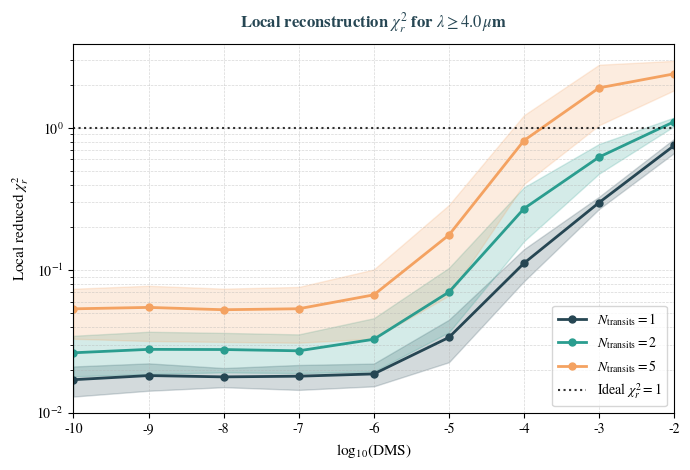

In [24]:
transit_color_map = {
    1: plot_palette["deep"],
    2: plot_palette["teal"],
    5: plot_palette["sand"],
}

fig, ax = plt.subplots(figsize=(7.0, 4.8))
fig.patch.set_facecolor("white")

for nt in NPLUS1_TRANSITS_LIST:
    one_nt = local_chi2_stats[local_chi2_stats["n_transits"] == nt].copy()
    x_vals = one_nt["atm DMS"].to_numpy(dtype=float)
    y_mean = one_nt["mean"].to_numpy(dtype=float)
    y_std = np.nan_to_num(one_nt["std"].to_numpy(dtype=float), nan=0.0)

    color = transit_color_map.get(nt, plot_palette["deep"])

    ax.plot(
        x_vals,
        y_mean,
        marker="o",
        markersize=5,
        linewidth=2.0,
        color=color,
        label=rf"$N_{{\rm transits}} = {nt}$",
    )
    ax.fill_between(
        x_vals,
        np.clip(y_mean - y_std, EPS_SIGMA, np.inf),
        np.clip(y_mean + y_std, EPS_SIGMA, np.inf),
        color=color,
        alpha=0.2,
    )

ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    label=r"Ideal $\chi^2_r = 1$",
)

ax.set_yscale("log")
ax.set_xticks(NPLUS1_DMS_GRID)
ax.set_xlim(NPLUS1_DMS_GRID[0], NPLUS1_DMS_GRID[-1])
ax.set_xlabel("log$_{10}$(DMS)", fontsize=11)
ax.set_ylabel(r"Local reduced $\chi^2_r$", fontsize=11)
ax.set_title(
    rf"Local reconstruction $\chi^2_r$ for $\lambda \geq {LOCAL_WL_MIN:.1f}\,\mu$m",
    color=plot_palette["deep"],
    fontsize=12,
    fontweight='bold',
    pad=12
)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(fontsize=10, frameon=True, facecolor="white", loc="best")

plt.tight_layout()
plt.show()

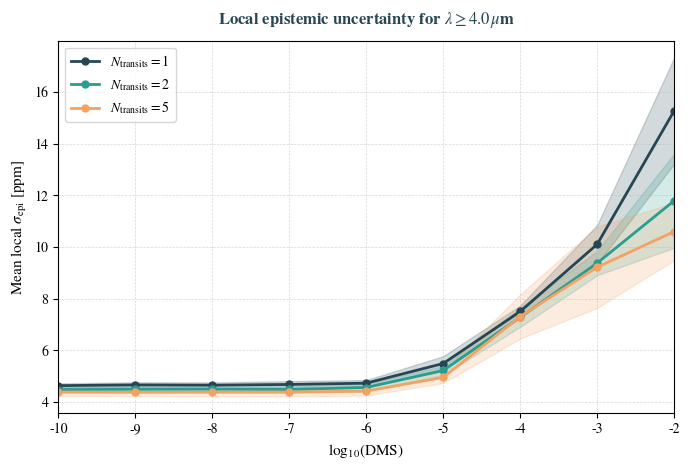

In [25]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))
fig.patch.set_facecolor("white")

for nt in NPLUS1_TRANSITS_LIST:
    one_nt = local_epi_stats[local_epi_stats["n_transits"] == nt].copy()
    x_vals = one_nt["atm DMS"].to_numpy(dtype=float)
    y_mean = one_nt["mean_ppm"].to_numpy(dtype=float)
    y_std = np.nan_to_num(one_nt["std_ppm"].to_numpy(dtype=float), nan=0.0)

    color = transit_color_map.get(nt, plot_palette["deep"])

    ax.plot(
        x_vals,
        y_mean,
        marker="o",
        markersize=5,
        linewidth=2.0,
        color=color,
        label=rf"$N_{{\rm transits}} = {nt}$",
    )
    ax.fill_between(
        x_vals,
        np.clip(y_mean - y_std, 0.0, np.inf),
        np.clip(y_mean + y_std, 0.0, np.inf),
        color=color,
        alpha=0.2,
    )

ax.set_xticks(NPLUS1_DMS_GRID)
ax.set_xlim(NPLUS1_DMS_GRID[0], NPLUS1_DMS_GRID[-1])
ax.set_xlabel("log$_{10}$(DMS)", fontsize=11)
ax.set_ylabel(r"Mean local $\sigma_{\rm epi}$ [ppm]", fontsize=11)
ax.set_title(
    rf"Local epistemic uncertainty for $\lambda \geq {LOCAL_WL_MIN:.1f}\,\mu$m",
    color=plot_palette["deep"],
    fontsize=12,
    fontweight='bold',
    pad=12
)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(fontsize=10, frameon=True, facecolor="white", loc="best")

plt.tight_layout()
plt.show()

### Epistemic Variance Fraction

It is useful to see what fraction of the *total* variance is epistemic.

$$
f_{\rm epi\_local} = \frac{\langle\sigma_{\rm epi}^2\rangle_{\rm local}}{\langle\sigma_{\rm total}^2\rangle_{\rm local}}
$$
This measures how quickly the model uncertainty overwhelms the instrumental noise.

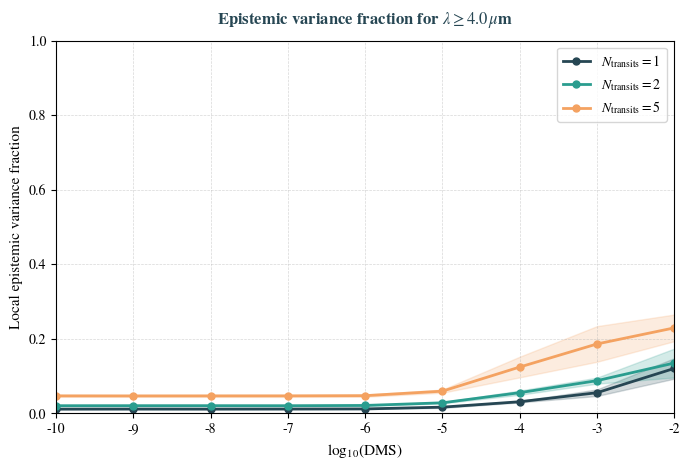

In [26]:
# Epistemic variance-budget fraction in the local long-wavelength window:
# f_epi_local = <sigma_epi^2>_local / <sigma_total^2>_local
#
# Since the local window has the same number of bins for every case,
# this is equivalent to:
# sum(sigma_epi^2) / sum(sigma_total^2)

frac_var_df = nplus1_local_results_df.copy()

for col in [
    "atm DMS",
    "n_transits",
    "sigma_epi2_local_mean",
    "sigma_total2_local_mean",
]:
    frac_var_df[col] = pd.to_numeric(frac_var_df[col], errors="coerce")

frac_var_df["n_transits"] = frac_var_df["n_transits"].astype(int)

frac_var_df["f_epi_var_local"] = (
    np.clip(frac_var_df["sigma_epi2_local_mean"].to_numpy(dtype=float), 0.0, np.inf)
    / np.clip(frac_var_df["sigma_total2_local_mean"].to_numpy(dtype=float), EPS_SIGMA, np.inf)
)

frac_var_stats = (
    frac_var_df
    .groupby(["n_transits", "atm DMS"])["f_epi_var_local"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["n_transits", "atm DMS"], ignore_index=True)
)

fig, ax = plt.subplots(figsize=(7.0, 4.8))
fig.patch.set_facecolor("white")

for nt in NPLUS1_TRANSITS_LIST:
    one_nt = frac_var_stats[frac_var_stats["n_transits"] == nt].copy()
    x_vals = one_nt["atm DMS"].to_numpy(dtype=float)
    y_mean = one_nt["mean"].to_numpy(dtype=float)
    y_std = np.nan_to_num(one_nt["std"].to_numpy(dtype=float), nan=0.0)

    color = transit_color_map.get(nt, plot_palette["deep"])

    ax.plot(
        x_vals,
        y_mean,
        marker="o",
        markersize=5,
        linewidth=2.0,
        color=color,
        label=rf"$N_{{\rm transits}} = {nt}$",
    )
    ax.fill_between(
        x_vals,
        np.clip(y_mean - y_std, 0.0, 1.0),
        np.clip(y_mean + y_std, 0.0, 1.0),
        color=color,
        alpha=0.2,
    )

ax.set_xticks(NPLUS1_DMS_GRID)
ax.set_xlim(NPLUS1_DMS_GRID[0], NPLUS1_DMS_GRID[-1])
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("log$_{10}$(DMS)", fontsize=11)
ax.set_ylabel(r"Local epistemic variance fraction", fontsize=11)
ax.set_title(
    rf"Epistemic variance fraction for $\lambda \geq {LOCAL_WL_MIN:.1f}\,\mu$m",
    color=plot_palette["deep"],
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(fontsize=10, frameon=True, facecolor="white", loc="best")

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_43160\3525780098.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


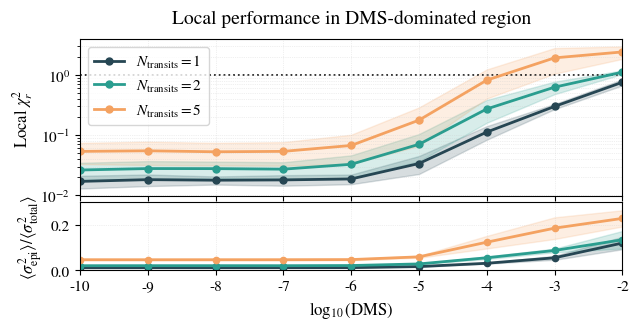

In [27]:
output_dir = "plots"

# Compact two-panel figure:
# Top: local reduced chi-square
# Bottom: local epistemic variance fraction
#
# This is more readable than an inset or a dual-axis figure.

# ---------- Summaries ----------

local_chi2_stats = (
    nplus1_local_results_df
    .groupby(["n_transits", "atm DMS"])["chi2r_recon_local"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["n_transits", "atm DMS"], ignore_index=True)
)

frac_var_df = nplus1_local_results_df.copy()

for col in [
    "atm DMS",
    "n_transits",
    "sigma_epi2_local_mean",
    "sigma_total2_local_mean",
]:
    frac_var_df[col] = pd.to_numeric(frac_var_df[col], errors="coerce")

frac_var_df["n_transits"] = frac_var_df["n_transits"].astype(int)

frac_var_df["f_epi_var_local"] = (
    np.clip(frac_var_df["sigma_epi2_local_mean"].to_numpy(dtype=float), 0.0, np.inf)
    / np.clip(frac_var_df["sigma_total2_local_mean"].to_numpy(dtype=float), EPS_SIGMA, np.inf)
)

frac_var_stats = (
    frac_var_df
    .groupby(["n_transits", "atm DMS"])["f_epi_var_local"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["n_transits", "atm DMS"], ignore_index=True)
)

# ---------- Figure ----------

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(7.0, 3.0),  
    sharex=True,
    gridspec_kw={"height_ratios": [2.3, 1.0], "hspace": 0.06},
)

fig.patch.set_facecolor("white")

for nt in NPLUS1_TRANSITS_LIST:
    color = transit_color_map.get(nt, plot_palette["deep"])

    # --- Top panel: chi2 ---
    one_nt_chi = local_chi2_stats[local_chi2_stats["n_transits"] == nt].copy()
    x_chi = one_nt_chi["atm DMS"].to_numpy(dtype=float)
    y_chi = one_nt_chi["mean"].to_numpy(dtype=float)
    y_chi_std = np.nan_to_num(one_nt_chi["std"].to_numpy(dtype=float), nan=0.0)

    ax1.plot(
        x_chi,
        y_chi,
        marker="o",
        markersize=5.0,
        linewidth=2.0,
        color=color,
        label=rf"$N_{{\rm transits}} = {nt}$",
    )
    ax1.fill_between(
        x_chi,
        np.clip(y_chi - y_chi_std, EPS_SIGMA, np.inf),
        np.clip(y_chi + y_chi_std, EPS_SIGMA, np.inf),
        color=color,
        alpha=0.18,
    )

    # --- Bottom panel: epistemic variance fraction ---
    one_nt_frac = frac_var_stats[frac_var_stats["n_transits"] == nt].copy()
    x_frac = one_nt_frac["atm DMS"].to_numpy(dtype=float)
    y_frac = one_nt_frac["mean"].to_numpy(dtype=float)
    y_frac_std = np.nan_to_num(one_nt_frac["std"].to_numpy(dtype=float), nan=0.0)

    ax2.plot(
        x_frac,
        y_frac,
        marker="o",
        markersize=4.5,
        linewidth=2.0,
        color=color,
    )
    ax2.fill_between(
        x_frac,
        np.clip(y_frac - y_frac_std, 0.0, 1.0),
        np.clip(y_frac + y_frac_std, 0.0, 1.0),
        color=color,
        alpha=0.18,
    )

# ---------- Styling ----------

ax1.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.3,
    alpha=0.85,
    zorder=1,
)

ax1.set_yscale("log")

# Nuevos textos de títulos y ejes basados en tu referencia
ax1.set_ylabel(r"Local $\chi_r^2$", fontsize=12)
ax1.set_title(
    "Local performance in DMS-dominated region",
    fontsize=14,
    pad=12,
)

# Estilo de malla como en la imagen
ax1.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.6, color="#cccccc")

# Estilo de la leyenda con recuadro (framon) y la métrica de tránsitos
ax1.legend(
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    loc="upper left",
)

ax2.set_ylabel(r"$\langle \sigma_{\rm epi}^2 \rangle / \langle \sigma_{\rm total}^2 \rangle$", fontsize=12)
ax2.set_xlabel(r"$\log_{10}(\rm{DMS})$", fontsize=12)
ax2.set_ylim(0.0, 0.30)
ax2.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#cccccc")

for ax in (ax1, ax2):
    ax.set_xlim(NPLUS1_DMS_GRID[0], NPLUS1_DMS_GRID[-1])
    ax.set_xticks(NPLUS1_DMS_GRID)
    ax.tick_params(axis='both', labelsize=11) # Dar un poco más de tamaño a los ticks

plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "exp3-DMS_N+1.png"),
    dpi=500,
    bbox_inches="tight",
)
plt.savefig(
    os.path.join(output_dir, "exp3-DMS_N+1.pdf"),
    dpi=500,
    bbox_inches="tight",
)
plt.show()